# Lofted Surface Voronoi Generation

This notebook builds a lofted surface from 8 circles defined by radii in `data/lofted_surface_inputs.json`. Each circle is created on the `XY` plane around the origin and then translated along `Z` in fixed `12` unit increments: `0, 12, 24, ...`.

The loft is sliced by the `YZ` plane through the origin, one side is kept, a padded bounding box is filled with random points from `data/voronoi_points_inputs.json`, a bounded 3D Voronoi diagram is generated, and the cells are intersected with the kept half of the loft. Any later non-uniform scaling uses the center of the initial loft bounding box as its pivot, scales only in `X` and `Y`, and keeps `Z` unchanged.

All intersection curves that hit the kept shape are retained. Closed curves stay closed, and open curves are closed by connecting their endpoints with one straight segment. Only cells with no intersection at all are discarded. The final output is shown as a shaded static render so it remains visible even when notebook widget rendering is unreliable.

In [1]:
import colorsys
import tempfile
from dataclasses import replace
from pathlib import Path
from uuid import uuid4

import ipywidgets as widgets
import numpy as np
import pyvista as pv
from IPython.display import Image, Markdown, display

from compass_web.lofted_surface_voronoi import (
    _build_staged_offset_lofts,
    _fan_surface_from_center,
    _loft_between_polylines,
    _merge_meshes,
    analyze_and_generate_surfaces,
    build_analysis_output_meshes,
    build_bounded_voronoi_cells,
    build_lofted_surface,
    build_mesh_printability_report,
    build_polyline_mesh,
    clean_meshes_without_naked_edges,
    clip_surface_in_half,
    count_connected_regions,
    close_mesh_boundaries,
    export_mesh_to_stl,
    extract_naked_edge_loops,
    extract_surface_mesh,
    filter_closed_meshes,
    remove_closed_regions,
    unify_mesh_normals,
    intersect_cells_with_surface,
    join_two_point_segments_into_polylines,
    load_generation_config,
    load_voronoi_point_config,
    pad_bounds,
    prepare_mesh_for_export,
    random_points_in_bounds,
    rebuild_polylines_from_discontinuities,
    resolve_non_manifold_faces,
    scale_points_in_xy,
    scale_polydata_in_xy,
)

pv.set_plot_theme("document")

MAX_MODEL_SPAN = 150.0
MIN_RADIUS = 5.0
MAX_RADIUS = 70.0
MAX_Z_INCREMENT = MAX_MODEL_SPAN / 7.0
SMALL_CELL_EXTRUSION_FACTOR = 0.1

surface_config_path = Path("data/lofted_surface_inputs.json")
point_config_path = Path("data/voronoi_points_inputs.json")
surface_config = load_generation_config(surface_config_path)
point_config = load_voronoi_point_config(point_config_path)


def make_float_control(
    *,
    value: float,
    min_value: float,
    max_value: float,
    step: float,
    description: str,
    readout_format: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.FloatSlider, widgets.BoundedFloatText]:
    slider = widgets.FloatSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    # The bounded text box gives a direct click-and-type way to enter exact values.
    text = widgets.BoundedFloatText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


def make_int_control(
    *,
    value: int,
    min_value: int,
    max_value: int,
    step: int,
    description: str,
    slider_width: str = "440px",
    input_width: str = "100px",
) -> tuple[widgets.HBox, widgets.IntSlider, widgets.BoundedIntText]:
    slider = widgets.IntSlider(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        description=description,
        continuous_update=False,
        readout=False,
        layout=widgets.Layout(width=slider_width),
        style={"description_width": "70px"},
    )
    text = widgets.BoundedIntText(
        value=value,
        min=min_value,
        max=max_value,
        step=step,
        layout=widgets.Layout(width=input_width),
    )
    widgets.jslink((slider, "value"), (text, "value"))
    row = widgets.HBox([slider, text])
    return row, slider, text


radius_controls = [
    make_float_control(
        value=float(radius),
        min_value=MIN_RADIUS,
        max_value=MAX_RADIUS,
        step=0.001,
        description=f"R{i + 1}",
        readout_format=".3f",
    )
    for i, radius in enumerate(surface_config.radii)
]
radius_rows = [row for row, _, _ in radius_controls]
radius_sliders = [slider for _, slider, _ in radius_controls]

spacing_row, spacing_slider, _ = make_float_control(
    value=float(surface_config.z_increment),
    min_value=4.0,
    max_value=MAX_Z_INCREMENT,
    step=0.01,
    description="Spacing",
    readout_format=".2f",
)
point_count_row, point_count_slider, _ = make_int_control(
    value=int(point_config.seed_count),
    min_value=2,
    max_value=300,
    step=1,
    description="Points",
)
seed_row, seed_slider, _ = make_int_control(
    value=int(point_config.random_seed),
    min_value=0,
    max_value=9999,
    step=1,
    description="Seed",
)
extrusion_row, extrusion_multiplier_slider, _ = make_float_control(
    value=-0.2,
    min_value=-3.0,
    max_value=3.0,
    step=0.05,
    description="Extrude",
    readout_format=".2f",
)
scale_x_row, scale_x_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale X",
    readout_format=".2f",
)
scale_y_row, scale_y_slider, _ = make_float_control(
    value=0.5,
    min_value=0.1,
    max_value=1.5,
    step=0.01,
    description="Scale Y",
    readout_format=".2f",
)


def validate_geometry_limits(radii: tuple[float, ...], z_increment: float) -> tuple[float, float]:
    max_width = 2.0 * max(radii)
    max_height = z_increment * (len(radii) - 1)
    if max_width > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The widest circle would produce {max_width:.2f} units in width, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    if max_height > MAX_MODEL_SPAN + 1e-9:
        raise ValueError(
            f"The stacked circles would span {max_height:.2f} units in Z, which is above the {MAX_MODEL_SPAN:.0f} unit limit."
        )
    return max_width, max_height


def get_active_surface_config():
    radii = tuple(float(slider.value) for slider in radius_sliders)
    z_increment = float(spacing_slider.value)
    validate_geometry_limits(radii, z_increment)
    z_levels = tuple(index * z_increment for index in range(len(radii)))
    return replace(surface_config, radii=radii, z_increment=z_increment, z_levels=z_levels)


def get_active_point_config():
    return replace(
        point_config,
        seed_count=int(point_count_slider.value),
        random_seed=int(seed_slider.value),
    )


def get_extrusion_multiplier() -> float:
    return float(extrusion_multiplier_slider.value)


def get_planar_scales() -> tuple[float, float]:
    return float(scale_x_slider.value), float(scale_y_slider.value)


# Geometry operations that are reused across notebook stages live in the module so the workflow cells stay shorter.


def polyline_point_keys(polyline: np.ndarray, tolerance: float) -> set[tuple[int, int, int]]:
    unique_points = polyline[:-1] if len(polyline) > 1 else polyline
    return {
        tuple(np.round(np.asarray(point, dtype=float) / tolerance).astype(int).tolist())
        for point in unique_points
    }


def filter_isolated_polylines(
    polylines: list[np.ndarray],
    tolerance: float,
) -> tuple[list[np.ndarray], list[int], list[int]]:
    if not polylines:
        return [], [], []
    point_key_sets = [polyline_point_keys(polyline, tolerance=tolerance) for polyline in polylines]
    kept_indices: list[int] = []
    discarded_indices: list[int] = []
    for index, point_keys in enumerate(point_key_sets):
        has_neighbor = any(
            index != other_index and len(point_keys.intersection(other_point_keys)) > 0
            for other_index, other_point_keys in enumerate(point_key_sets)
        )
        if has_neighbor:
            kept_indices.append(index)
        else:
            discarded_indices.append(index)
    return [polylines[index] for index in kept_indices], kept_indices, discarded_indices


display(
    Markdown(
        "### Geometry Controls\n\n"
        "These controls override the JSON defaults for this notebook run only. "
        "Every slider also has a bounded number field on the right so you can click and type exact values.\n\n"
        f"Design guardrails: total width must stay at or below {MAX_MODEL_SPAN:.0f} units and total Z height must also stay at or below {MAX_MODEL_SPAN:.0f} units. "
        "Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. "
        "The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged."
    )
)
display(
    widgets.VBox(
        [
            *radius_rows,
            spacing_row,
            point_count_row,
            seed_row,
            extrusion_row,
            scale_x_row,
            scale_y_row,
        ]
    )
)
(surface_config, point_config)


### Geometry Controls

These controls override the JSON defaults for this notebook run only. Every slider also has a bounded number field on the right so you can click and type exact values.

Design guardrails: total width must stay at or below 150 units and total Z height must also stay at or below 150 units. Width here is `2 * max(radius)`, and height is `7 * spacing` because the loft uses 8 circles. The `Extrude` control can be positive or negative, and the extra `Scale X` and `Scale Y` controls drive the non-uniform deformation applied later around the center of the initial loft bounding box while keeping `Z` unchanged.

(LoftedVoronoiConfig(radii=(8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46), z_levels=(0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001), z_increment=13.38, circle_resolution=120, slice_normal=(1.0, 0.0, 0.0), slice_origin=(0.0, 0.0, 0.0), bbox_padding=4.0, line_tolerance=0.001),
 VoronoiPointConfig(seed_count=78, random_seed=12))

In [2]:
# Read the latest widget values once so every downstream cell works from the same inputs.
active_surface_config = get_active_surface_config()
active_point_config = get_active_point_config()
raw_extrusion_multiplier = get_extrusion_multiplier()
extrusion_multiplier = 5.0 * raw_extrusion_multiplier
scale_x, scale_y = get_planar_scales()

# The widest section controls the total width because all circles are centered on the origin.
current_width = 2.0 * max(active_surface_config.radii)
current_height = active_surface_config.z_levels[-1] - active_surface_config.z_levels[0]

# Build the full loft first, then clip it in half along the YZ plane.
full_surface = build_lofted_surface(active_surface_config)
full_loft_bounds = full_surface.bounds
initial_loft_bbox_center = np.array(
    [
        0.5 * (full_loft_bounds[0] + full_loft_bounds[1]),
        0.5 * (full_loft_bounds[2] + full_loft_bounds[3]),
        0.5 * (full_loft_bounds[4] + full_loft_bounds[5]),
    ],
    dtype=float,
)
half_surface = clip_surface_in_half(
    full_surface,
    normal=active_surface_config.slice_normal,
    origin=active_surface_config.slice_origin,
)

# A slightly larger box is used later so the Voronoi cells stay finite before intersection.
padded_bounds = pad_bounds(half_surface.bounds, active_surface_config.bbox_padding)

print(f"Radii: {list(active_surface_config.radii)}")
print(f"Z positions: {list(active_surface_config.z_levels)}")
print(f"Current width: {current_width:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Current height: {current_height:.2f} / {MAX_MODEL_SPAN:.0f}")
print(f"Slice plane: YZ at x = {active_surface_config.slice_origin[0]}")
print(f"Voronoi seed points: {active_point_config.seed_count}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Extrusion slider value: {raw_extrusion_multiplier:.2f}")
print(f"Effective extrusion multiplier (x5): {extrusion_multiplier:.2f}")
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Full loft surface: {full_surface.n_points} points / {full_surface.n_cells} cells")
print(f"Kept half surface: {half_surface.n_points} points / {half_surface.n_cells} cells")
print(f"Padded bounds: {padded_bounds}")


Radii: [8.91, 10.446, 10.46, 17.66, 11.26, 19.299, 11.26, 14.46]
Z positions: [0.0, 13.38, 26.76, 40.14, 53.52, 66.9, 80.28, 93.66000000000001]
Current width: 38.60 / 150
Current height: 93.66 / 150
Slice plane: YZ at x = 0.0
Voronoi seed points: 78
Voronoi random seed: 12
Extrusion slider value: -0.20
Effective extrusion multiplier (x5): -1.00
Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 46.830000000000005]
Full loft surface: 960 points / 1680 cells
Kept half surface: 510 points / 868 cells
Padded bounds: (-4.0, 23.299, -23.299, 23.299, -4.0, 97.66000000000001)


In [3]:
# Fill the padded box with random points. These points are the seeds that define the Voronoi cells.
seed_points = random_points_in_bounds(
    bounds=padded_bounds,
    count=active_point_config.seed_count,
    seed=active_point_config.random_seed,
)

# Build finite Voronoi cells inside the padded box, then intersect them with the clipped loft.
voronoi_cells = build_bounded_voronoi_cells(seed_points, padded_bounds)
raw_closed_polylines = intersect_cells_with_surface(
    surface=half_surface,
    cells=voronoi_cells,
    tolerance=active_surface_config.line_tolerance,
)
closed_polylines, kept_polyline_indices, discarded_polyline_indices = filter_isolated_polylines(
    raw_closed_polylines,
    tolerance=active_surface_config.line_tolerance,
)
retained_intersection_polyline_count = len(closed_polylines)
polyline_snap_tolerance = max(20.0 * active_surface_config.line_tolerance, 0.02)
closed_polylines = rebuild_polylines_from_discontinuities(
    closed_polylines,
    tolerance=active_surface_config.line_tolerance,
    discontinuity_angle_degrees=176.0,
    neighbor_snap_tolerance=polyline_snap_tolerance,
)
polyline_mesh = build_polyline_mesh(closed_polylines)
discarded_polyline_mesh = build_polyline_mesh([raw_closed_polylines[index] for index in discarded_polyline_indices])

print(f"Random seed points: {len(seed_points)}")
print(f"Voronoi random seed: {active_point_config.random_seed}")
print(f"Bounded Voronoi cells: {len(voronoi_cells)}")
print(f"Raw surface intersection polylines: {len(raw_closed_polylines)}")
print(f"Surface intersection polylines kept after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(closed_polylines)}")
print(f"Polyline snap tolerance used: {polyline_snap_tolerance:.4f}")
print(f"Discarded isolated polylines: {len(discarded_polyline_indices)}")
print(f"Polyline mesh lines: {polyline_mesh.n_lines}")


Random seed points: 78
Voronoi random seed: 12
Bounded Voronoi cells: 78
Raw surface intersection polylines: 52
Surface intersection polylines kept after neighbor filter: 51
Rebuilt line polylines used downstream: 51
Polyline snap tolerance used: 0.0200
Discarded isolated polylines: 1
Polyline mesh lines: 51


In [4]:
# Analyze each retained curve and generate the derived surface patches.
curve_result = analyze_and_generate_surfaces(
    closed_polylines,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    extrusion_scale_origin=initial_loft_bbox_center,
    planar_scale_factors=(scale_x, scale_y),
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_original_polylines = [analysis.original_polyline for analysis in curve_result.analyses]
analysis_followup_polylines = [analysis.followup_polyline for analysis in curve_result.analyses]
followup_polyline_mesh = build_polyline_mesh(list(curve_result.followup_polylines))
bbox_edge_meshes = [analysis.bbox_mesh.extract_all_edges() for analysis in curve_result.analyses]
circle_centers = np.array([analysis.circle_center for analysis in curve_result.analyses], dtype=float)
scaled_circle_centers = np.array([analysis.scaled_circle_center for analysis in curve_result.analyses], dtype=float)
extrusion_base_vectors = np.array([analysis.extrusion_base_vector for analysis in curve_result.analyses], dtype=float)
extrusion_base_lengths = np.linalg.norm(extrusion_base_vectors, axis=1) if len(curve_result.analyses) > 0 else np.zeros(0, dtype=float)
curve_lengths = np.array([analysis.curve_length for analysis in curve_result.analyses], dtype=float)
bbox_volumes = np.array([analysis.bbox_volume for analysis in curve_result.analyses], dtype=float)
ratios = np.array([analysis.ratio for analysis in curve_result.analyses], dtype=float)
sorted_indices = np.argsort(ratios)[::-1]
large_curve_count = sum(analysis.ratio >= curve_result.average_ratio for analysis in curve_result.analyses)
small_curve_count = len(curve_result.analyses) - large_curve_count
discontinuity_point_sets = [analysis.discontinuity_points for analysis in curve_result.analyses]
all_discontinuity_points = (
    np.vstack([points for points in discontinuity_point_sets if len(points) > 0])
    if any(len(points) > 0 for points in discontinuity_point_sets)
    else np.zeros((0, 3), dtype=float)
)
curve_colors = [
    "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / len(curve_result.analyses), 0.7, 1.0))
    for index in range(len(curve_result.analyses))
] if curve_result.analyses else []
curve_label_points = np.array([
    analysis.followup_polyline[:-1].mean(axis=0) for analysis in curve_result.analyses
], dtype=float) if curve_result.analyses else np.zeros((0, 3), dtype=float)
curve_labels = [f"crv {index + 1}" for index in range(len(curve_result.analyses))]
analysis_output_result = build_analysis_output_meshes(
    curve_result.analyses,
    average_ratio=curve_result.average_ratio,
    loft_bounds=full_surface.bounds,
    tolerance=active_surface_config.line_tolerance,
    extrusion_multiplier=extrusion_multiplier,
    small_cell_extrusion_factor=SMALL_CELL_EXTRUSION_FACTOR,
    slice_plane_x=active_surface_config.slice_origin[0],
)
analysis_preview_output_meshes = list(analysis_output_result.preview_meshes)
analysis_output_meshes = list(analysis_output_result.output_meshes)
analysis_output_modes = list(analysis_output_result.output_modes)
removed_by_retained_volume_indices = list(analysis_output_result.removed_by_retained_volume_indices)

mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
merge_ready_output_meshes = list(mesh_cleanup.kept_meshes)
merge_ready_output_surfaces = list(mesh_cleanup.kept_surface_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)
generated_surface = _merge_meshes(merge_ready_output_meshes) if merge_ready_output_meshes else half_surface
generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

print(f"Analyzed curves: {len(curve_result.analyses)}")
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier used: {extrusion_multiplier:.2f}")
print(f"Small-cell extrusion factor: {SMALL_CELL_EXTRUSION_FACTOR:.2f}")
print(f"Scaled-center extrusion pivot: {initial_loft_bbox_center.tolist()}")
print(f"Planar scaling used for center vectors (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Curves classified as large: {large_curve_count}")
print(f"Curves classified as small: {small_curve_count}")
print(f"Generated surface faces after retained-volume filtering and naked-edge cleanup: {generated_surface.n_cells}")
print(f"Cells removed by retained-volume criterion: {len(removed_by_retained_volume_indices)}")
print(f"Cells kept for downstream merge: {len(merge_ready_output_meshes)}")
print(f"Cells removed because they have no naked edges: {len(removed_output_mesh_indices)}")
print(f"Large-curve loft faces: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'large')}")
print(f"Small-curve fan faces after retained-volume criterion: {sum(mesh.n_cells for mesh, mode in zip(analysis_output_meshes, analysis_output_modes, strict=True) if mode == 'small')}")
if len(extrusion_base_lengths) > 0:
    print(
        f"Scaled-center vector lengths - min: {extrusion_base_lengths.min():.3f}, "
        f"max: {extrusion_base_lengths.max():.3f}, "
        f"mean: {extrusion_base_lengths.mean():.3f}"
    )
if curve_result.followup_polylines:
    print(
        f"Working polyline segments - min: {min(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"max: {max(len(polyline) - 1 for polyline in curve_result.followup_polylines)}, "
        f"mean: {np.mean([len(polyline) - 1 for polyline in curve_result.followup_polylines]):.1f}"
    )
else:
    print("Working polyline segments: no retained curves were generated.")
print(f"Discontinuity markers total: {len(all_discontinuity_points)}")

top_count = min(8, len(sorted_indices))
summary_rows = [
    (
        int(index),
        float(ratios[index]),
        float(bbox_volumes[index]),
        float(curve_lengths[index]),
    )
    for index in sorted_indices[:top_count]
]
summary_rows


Analyzed curves: 51
Average volume/length ratio: 7.8474
Extrusion multiplier used: -1.00
Small-cell extrusion factor: 0.10
Scaled-center extrusion pivot: [0.0, 0.0, 46.830000000000005]
Planar scaling used for center vectors (X, Y) with Z fixed: (0.50, 0.50)
Curves classified as large: 21
Curves classified as small: 30
Generated surface faces after retained-volume filtering and naked-edge cleanup: 2472
Cells removed by retained-volume criterion: 3
Cells kept for downstream merge: 48
Cells removed because they have no naked edges: 3
Large-curve loft faces: 2112
Small-curve fan faces after retained-volume criterion: 360
Scaled-center vector lengths - min: 3.281, max: 9.325, mean: 6.521
Working polyline segments - min: 3, max: 41, mean: 17.8
Discontinuity markers total: 908


[(41, 35.64886333710609, 2232.123348292467, 62.61415201895374),
 (20, 26.932525213523004, 1554.6097910809362, 57.72239248848289),
 (37, 26.223838177599113, 1403.3444908089336, 53.51407682219823),
 (9, 25.835525035773607, 1447.3738678510413, 56.02262256512728),
 (11, 22.54743235105585, 1151.6338701901543, 51.07605390536744),
 (30, 22.24505402337992, 1168.0954018185823, 52.5103423255747),
 (16, 21.424221427211066, 1037.347165298109, 48.41936351444569),
 (25, 19.084803379295586, 992.3308393691851, 51.99586391577547)]

In [5]:
def distinct_colors(count: int) -> list[str]:
    if count <= 0:
        return []
    return [
        "#%02x%02x%02x" % tuple(int(channel * 255) for channel in colorsys.hsv_to_rgb(index / count, 0.7, 1.0))
        for index in range(count)
    ]


def camera_position_from_bounds(
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
) -> list[list[float]]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    max_span = max(xmax - xmin, ymax - ymin, zmax - zmin, 1.0)
    target_array = np.asarray(target, dtype=float)
    # This keeps a readable three-quarter view while allowing the fitted bounds to control the final framing.
    camera_position = target_array + np.array([1.05 * max_span, -1.45 * max_span, 0.78 * max_span], dtype=float)
    return [camera_position.tolist(), target_array.tolist(), [0.0, 0.0, 1.0]]


def merge_bounds(bounds_list: list[tuple[float, float, float, float, float, float]]) -> tuple[float, float, float, float, float, float]:
    if not bounds_list:
        raise ValueError("bounds_list must not be empty.")
    mins = np.array([[bounds[0], bounds[2], bounds[4]] for bounds in bounds_list], dtype=float)
    maxs = np.array([[bounds[1], bounds[3], bounds[5]] for bounds in bounds_list], dtype=float)
    min_corner = mins.min(axis=0)
    max_corner = maxs.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def bounds_from_points(points: np.ndarray) -> tuple[float, float, float, float, float, float] | None:
    if len(points) == 0:
        return None
    points_array = np.asarray(points, dtype=float)
    min_corner = points_array.min(axis=0)
    max_corner = points_array.max(axis=0)
    return (
        float(min_corner[0]),
        float(max_corner[0]),
        float(min_corner[1]),
        float(max_corner[1]),
        float(min_corner[2]),
        float(max_corner[2]),
    )


def padded_scene_bounds(
    bounds: tuple[float, float, float, float, float, float],
    padding_fraction: float = 0.22,
    min_padding: float = 1.0,
) -> tuple[float, float, float, float, float, float]:
    xmin, xmax, ymin, ymax, zmin, zmax = bounds
    spans = np.array([xmax - xmin, ymax - ymin, zmax - zmin], dtype=float)
    padding = np.maximum(spans * padding_fraction, min_padding)
    return (
        float(xmin - padding[0]),
        float(xmax + padding[0]),
        float(ymin - padding[1]),
        float(ymax + padding[1]),
        float(zmin - padding[2]),
        float(zmax + padding[2]),
    )


def center_from_bounds(bounds: tuple[float, float, float, float, float, float]) -> np.ndarray:
    return np.array(
        [
            0.5 * (bounds[0] + bounds[1]),
            0.5 * (bounds[2] + bounds[3]),
            0.5 * (bounds[4] + bounds[5]),
        ],
        dtype=float,
    )


def add_scene_content(
    plotter: pv.Plotter,
    *,
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
) -> None:
    for mesh, kwargs in meshes or []:
        if mesh.n_points == 0:
            continue
        plotter.add_mesh(mesh, **kwargs)

    for line_mesh, kwargs in line_meshes or []:
        if line_mesh.n_points == 0:
            continue
        plotter.add_mesh(line_mesh, render_lines_as_tubes=True, **kwargs)

    for points, kwargs in point_sets or []:
        if len(points) == 0:
            continue
        plotter.add_points(np.asarray(points, dtype=float), **kwargs)

    for points, labels, kwargs in label_sets or []:
        if len(points) == 0 or not labels:
            continue
        plotter.add_point_labels(np.asarray(points, dtype=float), labels, **kwargs)


def render_static_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.1,
    window_size: tuple[int, int] = (1100, 820),
) -> bytes:
    plotter = pv.Plotter(off_screen=True, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )

    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    # Static images have no orbit controls, so a mild zoom helps the fitted scene occupy more of the screenshot.
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")

    image_path = Path(tempfile.gettempdir()) / f"{uuid4().hex}.png"
    try:
        plotter.screenshot(str(image_path))
        return image_path.read_bytes()
    finally:
        plotter.close()
        image_path.unlink(missing_ok=True)


def display_static_scene(**kwargs: object) -> None:
    display(Image(data=render_static_scene(**kwargs)))


def display_interactive_scene(
    *,
    title: str,
    bounds: tuple[float, float, float, float, float, float],
    target: np.ndarray | list[float] | tuple[float, float, float],
    meshes: list[tuple[pv.DataSet, dict[str, object]]] | None = None,
    line_meshes: list[tuple[pv.PolyData, dict[str, object]]] | None = None,
    point_sets: list[tuple[np.ndarray, dict[str, object]]] | None = None,
    label_sets: list[tuple[np.ndarray, list[str], dict[str, object]]] | None = None,
    fit_bounds: tuple[float, float, float, float, float, float] | None = None,
    fit_target: np.ndarray | list[float] | tuple[float, float, float] | None = None,
    zoom_factor: float = 1.0,
    window_size: tuple[int, int] = (1200, 900),
) -> None:
    # PyVista's notebook html/trame backends are not available in this environment,
    # so the interactive inspection opens in a native VTK window instead.
    plotter = pv.Plotter(notebook=False, window_size=window_size)
    plotter.set_background("#1a1a2e")
    add_scene_content(
        plotter,
        meshes=meshes,
        line_meshes=line_meshes,
        point_sets=point_sets,
        label_sets=label_sets,
    )
    plotter.add_axes()
    camera_bounds = fit_bounds if fit_bounds is not None else bounds
    camera_target = np.asarray(fit_target if fit_target is not None else target, dtype=float)
    plotter.camera_position = camera_position_from_bounds(camera_bounds, camera_target)
    plotter.camera.zoom(zoom_factor)
    plotter.add_text(title, position="upper_left", font_size=12, color="white")
    plotter.show()


def selected_curve_indices(curve_index: int, curve_count: int, show_all_up_to: bool) -> list[int]:
    if curve_index <= 0:
        return []
    if show_all_up_to:
        return list(range(min(curve_index, curve_count)))
    return [min(curve_index, curve_count) - 1]


def build_selected_discontinuity_points(indices: list[int]) -> np.ndarray:
    selected_sets = [discontinuity_point_sets[index] for index in indices if len(discontinuity_point_sets[index]) > 0]
    if not selected_sets:
        return np.zeros((0, 3), dtype=float)
    return np.vstack(selected_sets)


def build_selected_centers(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return circle_centers[indices]


def build_selected_curve_label_points(indices: list[int]) -> np.ndarray:
    if not indices:
        return np.zeros((0, 3), dtype=float)
    return curve_label_points[indices]


def build_selected_curve_labels(indices: list[int]) -> list[str]:
    return [curve_labels[index] for index in indices]


def build_selected_curve_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            build_polyline_mesh([analysis_followup_polylines[index]]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index in indices
    ]


def build_selected_output_layers(indices: list[int]) -> list[tuple[pv.PolyData, dict[str, object]]]:
    return [
        (
            analysis_preview_output_meshes[index],
            {
                "color": curve_colors[index],
                "opacity": 1.0,
                "smooth_shading": True,
            },
        )
        for index in indices
        if analysis_preview_output_meshes[index].n_points > 0
    ]


def selected_curve_view_fit(indices: list[int]) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(half_surface.bounds, padding_fraction=0.08), np.asarray(half_surface.center, dtype=float)
    fit_bounds_list = [
        build_polyline_mesh([analysis_followup_polylines[index]]).bounds
        for index in indices
        if len(analysis_followup_polylines[index]) > 0
    ]
    point_bounds = bounds_from_points(build_selected_discontinuity_points(indices))
    label_bounds = bounds_from_points(build_selected_curve_label_points(indices))
    if point_bounds is not None:
        fit_bounds_list.append(point_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else half_surface.bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.3, min_padding=1.5)
    return padded, center_from_bounds(padded)


def selected_output_view_fit(indices: list[int], show_final: bool) -> tuple[tuple[float, float, float, float, float, float], np.ndarray]:
    if not indices:
        return padded_scene_bounds(generated_bounds, padding_fraction=0.08), np.asarray(generated_target, dtype=float)
    selected_meshes = (
        [analysis_output_meshes[index] for index in indices if analysis_output_meshes[index].n_points > 0]
        if show_final
        else [analysis_preview_output_meshes[index] for index in indices if analysis_preview_output_meshes[index].n_points > 0]
    )
    fit_bounds_list = [mesh.bounds for mesh in selected_meshes]
    center_bounds = bounds_from_points(build_selected_centers(indices))
    label_bounds = bounds_from_points(build_selected_centers(indices))
    if center_bounds is not None:
        fit_bounds_list.append(center_bounds)
    if label_bounds is not None:
        fit_bounds_list.append(label_bounds)
    merged = merge_bounds(fit_bounds_list) if fit_bounds_list else generated_bounds
    padded = padded_scene_bounds(merged, padding_fraction=0.32, min_padding=1.5)
    return padded, center_from_bounds(padded)


def make_curve_subset_browser() -> None:
    curve_row, slider, _ = make_int_control(
        value=0,
        min_value=0,
        max_value=len(analysis_followup_polylines),
        step=1,
        description="Curve",
        slider_width="320px",
        input_width="90px",
    )
    show_all_checkbox = widgets.Checkbox(
        value=True,
        description="Show all from 0 to selected curve",
    )
    show_final_checkbox = widgets.Checkbox(
        value=False,
        description="Show generated output surfaces",
    )
    summary = widgets.HTML()
    details = widgets.HTML(layout=widgets.Layout(max_height="180px", overflow="auto"))
    curves_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))
    outputs_image = widgets.Image(format="png", layout=widgets.Layout(width="540px"))

    def update_view(_: object | None = None) -> None:
        indices = selected_curve_indices(slider.value, len(analysis_followup_polylines), show_all_checkbox.value)
        selected_points = build_selected_discontinuity_points(indices)
        selected_centers = build_selected_centers(indices)
        selected_label_points = build_selected_curve_label_points(indices)
        selected_labels = build_selected_curve_labels(indices)
        selected_modes = [analysis_output_modes[index] for index in indices]
        output_title = "Generated output surfaces for the selected curves" if show_final_checkbox.value else "Preview loft bands for the selected curves"
        curve_layers = build_selected_curve_layers(indices)
        preview_output_layers = build_selected_output_layers(indices)
        final_output_layers = [
            (
                analysis_output_meshes[index],
                {
                    "color": curve_colors[index],
                    "opacity": 1.0,
                    "smooth_shading": True,
                },
            )
            for index in indices
            if analysis_output_meshes[index].n_points > 0
        ]
        curve_fit_bounds, curve_fit_target = selected_curve_view_fit(indices)
        output_fit_bounds, output_fit_target = selected_output_view_fit(indices, show_final_checkbox.value)
        summary.value = (
            f"<b>Selected curves:</b> {len(indices)}"
            f" | <b>Large outputs:</b> {sum(mode == 'large' for mode in selected_modes)}"
            f" | <b>Small outputs:</b> {sum(mode == 'small' for mode in selected_modes)}"
            f" | <b>Output mode:</b> {'generated output' if show_final_checkbox.value else 'preview loft bands'}"
            " | <b>Curve 0</b> means hide all curves and generated outputs."
        )
        if indices:
            detail_rows = [
                f"<li><b>{curve_labels[index]}</b> | class: {analysis_output_modes[index]} | ratio: {ratios[index]:.2f} | length: {curve_lengths[index]:.2f} | discontinuities: {len(discontinuity_point_sets[index])}</li>"
                for index in indices
            ]
            details.value = "<b>Selected curve info</b><ul>" + "".join(detail_rows) + "</ul>"
        else:
            details.value = "<b>Selected curve info</b><div>No curve selected.</div>"
        curves_image.value = render_static_scene(
            title="Selected retained curves and discontinuity markers",
            bounds=half_surface.bounds,
            target=half_surface.center,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#727272",
                        "opacity": 0.12,
                        "smooth_shading": True,
                    },
                ),
            ],
            line_meshes=curve_layers,
            point_sets=[
                (
                    selected_points,
                    {
                        "color": "#ff4d4d",
                        "point_size": 13,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_label_points,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=curve_fit_bounds,
            fit_target=curve_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )
        outputs_image.value = render_static_scene(
            title=output_title,
            bounds=generated_bounds,
            target=generated_target,
            meshes=[
                (
                    half_surface,
                    {
                        "color": "#808080",
                        "opacity": 0.08,
                        "smooth_shading": True,
                    },
                ),
                *(preview_output_layers if not show_final_checkbox.value else final_output_layers),
            ],
            point_sets=[
                (
                    selected_centers,
                    {
                        "color": "#ffe082",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                        "opacity": 1.0,
                    },
                ),
            ],
            label_sets=[
                (
                    selected_centers,
                    selected_labels,
                    {
                        "shape_opacity": 0.2,
                        "fill_shape": True,
                        "font_size": 16,
                        "text_color": "white",
                        "point_color": "#ffe082",
                        "margin": 4,
                        "show_points": False,
                        "always_visible": True,
                    },
                ),
            ],
            fit_bounds=output_fit_bounds,
            fit_target=output_fit_target,
            zoom_factor=1.18,
            window_size=(1000, 760),
        )

    slider.observe(update_view, names="value")
    show_all_checkbox.observe(update_view, names="value")
    show_final_checkbox.observe(update_view, names="value")
    update_view()

    display(
        widgets.VBox(
            [
                curve_row,
                widgets.HBox([show_all_checkbox, show_final_checkbox]),
                summary,
                widgets.HBox([curves_image, outputs_image]),
                details,
            ]
        )
    )


def show_step(title: str, explanation: str) -> None:
    display(Markdown(f"### {title}\n\n{explanation}"))


## Geometry Walkthrough

This section keeps the workflow visual and beginner-friendly. The controls at the top now let you either drag or type exact values for the radii, circle spacing, Voronoi point count, Voronoi seed, extrusion multiplier, and the two planar scaling values for `X` and `Y` before rerunning the downstream cells.

1. Build the loft from the 8 circle sections and clip it with the `YZ` plane so the workflow operates on only one side of the shape.
2. Expand that kept half with a padded bounding box and place random seed points inside it so every Voronoi region becomes bounded instead of shooting off to infinity.
3. Filter out isolated intersection cells that share no direct boundary points with other cells, then show the retained intersection curves with one color per curve.
4. Use the curve browser to reveal either one selected curve or all curves up to the selected index, together with their corresponding generated outputs. The red markers are detected from tangent breaks together with curvature-transition boundaries, not just obvious kinks.
5. Show the generated open surface patches exactly as they come out of the curved-loop follow-up stage, now using extrusion vectors built from each original fitted-circle center to its non-uniformly scaled counterpart.
6. In a new code cell, merge all of those open patches into one larger open geometry while keeping the holes and open boundaries intact.
7. In the next code cell, create a second unit by applying the same non-uniform `X/Y` scale to that merged open geometry around the center of the initial loft bounding box while keeping `Z` unchanged.
8. In another code cell, extract and visualize the naked edges of both open units so it is easy to confirm whether the boundaries are only the exterior loops and holes.
9. Loft between the corresponding naked-edge loops and merge those loft bands with the two open units, then check whether any naked edges remain.
10. Use the interactive 3D view to orbit, pan, and zoom around the assembled result.
11. Export the final assembled geometry to STL.

The size guardrails stay explicit throughout the notebook: total width is `2 * max(radius)` and total height is `7 * spacing`, and both must stay at or below `150` units. The reason for this step-by-step layout is that each later result depends on geometry extracted from the previous one, so seeing the intermediate state makes it much easier to understand why the final surfaces look the way they do.


### Step 1: Loft the circles and clip the shape in half

The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.

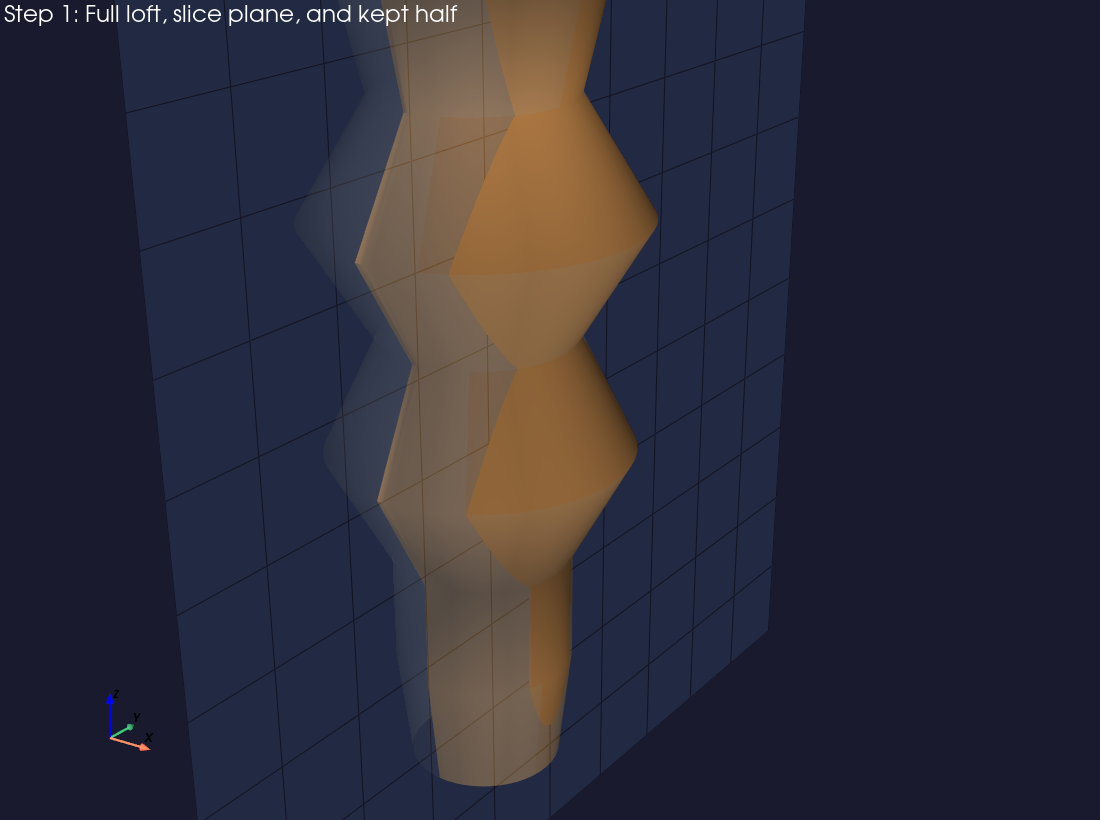

In [6]:
plane_size = 1.15 * max(
    full_surface.bounds[1] - full_surface.bounds[0],
    full_surface.bounds[3] - full_surface.bounds[2],
    full_surface.bounds[5] - full_surface.bounds[4],
)
slice_plane = pv.Plane(
    center=half_surface.center,
    direction=active_surface_config.slice_normal,
    i_size=plane_size,
    j_size=plane_size,
)

show_step(
    "Step 1: Loft the circles and clip the shape in half",
    "The eight circular sections are connected into one lofted skin. The blue plane is the YZ slicing plane at x = 0, and the solid orange surface is the kept half. This clip removes the mirrored side so the later Voronoi intersections are easier to interpret and do not duplicate across both halves.",
)
display_static_scene(
    title="Step 1: Full loft, slice plane, and kept half",
    bounds=full_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            full_surface,
            {
                "color": "#d9d9d9",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            slice_plane,
            {
                "color": "#6aa9ff",
                "opacity": 0.25,
                "show_edges": True,
            },
        ),
        (
            half_surface,
            {
                "color": "#ffb366",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)


### Step 2: Seed the padded box for the bounded Voronoi construction

The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.

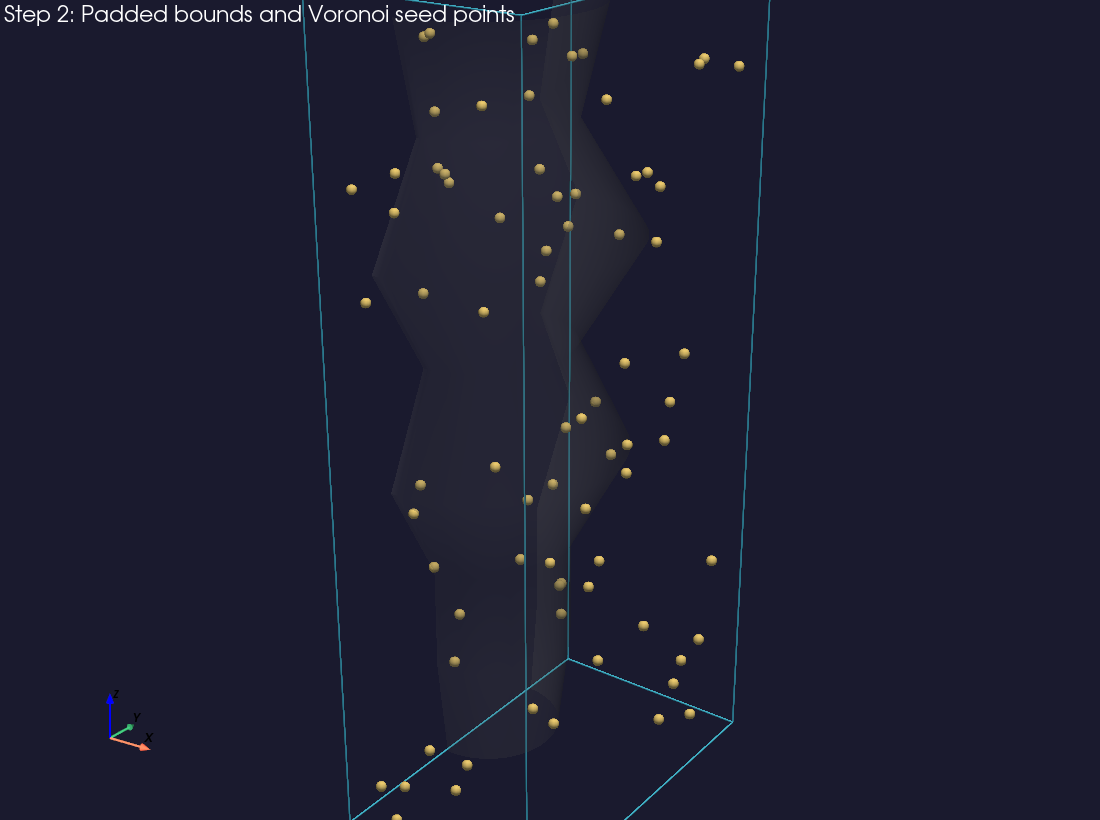

In [7]:
padded_box_edges = pv.Box(bounds=padded_bounds).extract_all_edges()

show_step(
    "Step 2: Seed the padded box for the bounded Voronoi construction",
    "The cyan box is slightly larger than the kept loft half, and the yellow points are the random Voronoi seeds inside it. The padding matters because an unconstrained 3D Voronoi diagram would create infinite cells; this box forces every cell to stay finite before we intersect it with the loft.",
)
display_static_scene(
    title="Step 2: Padded bounds and Voronoi seed points",
    bounds=padded_bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#8c8c8c",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            padded_box_edges,
            {
                "color": "#4dd7ff",
                "line_width": 2,
                "opacity": 0.95,
            },
        ),
    ],
    point_sets=[
        (
            seed_points,
            {
                "color": "#ffe082",
                "point_size": 11,
                "render_points_as_spheres": True,
                "opacity": 1.0,
            },
        ),
    ],
)


### Step 3: View every rebuilt intersection polyline as a separate colored trace

Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.

Raw intersection loops: 52
Retained intersection loops after neighbor filter: 51
Rebuilt line polylines used downstream: 51
Discarded isolated loops: 1


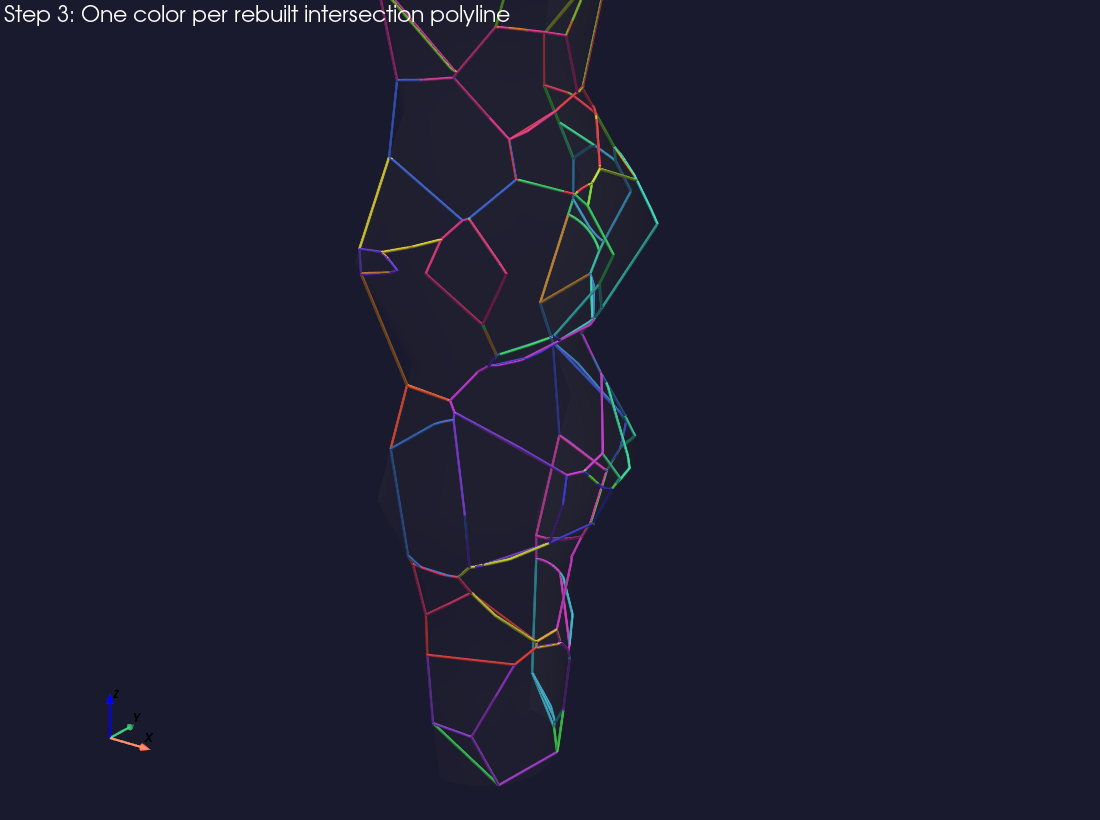

### Step 3A: Interactive inspection of the rebuilt intersection polylines

This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.

In [8]:
show_step(
    "Step 3: View every rebuilt intersection polyline as a separate colored trace",
    "Each colored polyline is rebuilt from the detected discontinuity points of one retained intersection curve. Close vertices from neighboring cells are snapped together before anything downstream uses these polylines, which helps the later surface mesh stay closed without tiny breaks.",
)
print(f"Raw intersection loops: {len(raw_closed_polylines)}")
print(f"Retained intersection loops after neighbor filter: {retained_intersection_polyline_count}")
print(f"Rebuilt line polylines used downstream: {len(analysis_original_polylines)}")
print(f"Discarded isolated loops: {len(discarded_polyline_indices)}")
display_static_scene(
    title="Step 3: One color per rebuilt intersection polyline",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
)
show_step(
    "Step 3A: Interactive inspection of the rebuilt intersection polylines",
    "This opens the rebuilt and snapped intersection polylines in a native PyVista window so you can orbit, pan, and zoom around the clipped loft while checking how the downstream working curves sit on the surface.",
)
display_interactive_scene(
    title="Step 3A: Interactive rebuilt intersection polylines",
    bounds=half_surface.bounds,
    target=half_surface.center,
    meshes=[
        (
            half_surface,
            {
                "color": "#727272",
                "opacity": 0.13,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            build_polyline_mesh([polyline]),
            {
                "color": curve_colors[index],
                "line_width": 3,
                "opacity": 1.0,
            },
        )
        for index, polyline in enumerate(analysis_original_polylines)
    ],
    zoom_factor=1.15,
    window_size=(1300, 950),
)


In [9]:
show_step(
    "Step 4: Optional subset browser",
    "Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact working polyline you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between the preview loft bands and the generated output surfaces.",
)
print(f"Working polylines available in the browser: {len(analysis_followup_polylines)}")
print("Curve value 0 hides all curves and generated outputs.")
make_curve_subset_browser()


### Step 4: Optional subset browser

Step 3 already shows the full picture. This browser is only for inspection of subsets. Use the curve control to choose an index from 0 to N. You can drag the slider or click into the numeric field to type the exact working polyline you want. With the checkbox enabled, the browser shows all curves from 0 up to the selected value. With it disabled, the browser shows only the corresponding curve. A second checkbox switches the right image between the preview loft bands and the generated output surfaces.

Working polylines available in the browser: 51
Curve value 0 hides all curves and generated outputs.


In [10]:
show_step(
    "Step 4B: Interactive cell inspector (curve / surface / naked edges)",
    "Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.",
)

cell_inspector_slider_row, cell_inspector_slider, _ = make_int_control(
    value=1,
    min_value=1,
    max_value=len(analysis_followup_polylines),
    step=1,
    description="Cell",
    slider_width="340px",
    input_width="90px",
)
cell_inspector_show_all = widgets.Checkbox(
    value=False,
    description="Show all cells from 0 to selected",
)
cell_inspector_summary = widgets.HTML()
cell_inspector_report = widgets.HTML(layout=widgets.Layout(max_height="280px", overflow="auto"))
cell_inspector_open = widgets.Button(
    description="Open interactive cell views",
    button_style="success",
)
cell_inspector_output = widgets.Output()

from compass_web.lofted_surface_voronoi import _fit_plane


def _cell_inspector_indices() -> list[int]:
    val = int(cell_inspector_slider.value)
    if val <= 0:
        return []
    if cell_inspector_show_all.value:
        return list(range(min(val, len(analysis_followup_polylines))))
    return [min(val, len(analysis_followup_polylines)) - 1]


def _cell_diagnostic(idx: int) -> dict:
    from collections import defaultdict as _dd
    a = curve_result.analyses[idx]
    mesh = analysis_output_meshes[idx]
    mode = analysis_output_modes[idx]
    if mesh.n_cells == 0:
        return {"idx": idx, "mode": mode, "empty": True}
    surf = extract_surface_mesh(mesh)
    pts = np.asarray(surf.points, dtype=float)
    fraw = np.asarray(surf.faces, dtype=int)
    fv = []
    c = 0
    while c < len(fraw):
        n = int(fraw[c])
        if n == 3:
            fv.append((int(fraw[c+1]), int(fraw[c+2]), int(fraw[c+3])))
        c += n + 1
    norms = []
    areas = []
    for aa, bb, cc in fv:
        e1 = pts[bb] - pts[aa]; e2 = pts[cc] - pts[aa]; nn = np.cross(e1, e2)
        nl = float(np.linalg.norm(nn))
        norms.append(nn / nl if nl > 1e-12 else np.zeros(3))
        areas.append(float(nl) * 0.5)
    etf = _dd(list)
    for fi, (aa, bb, cc) in enumerate(fv):
        for e in [(min(aa,bb),max(aa,bb)),(min(bb,cc),max(bb,cc)),(min(aa,cc),max(aa,cc))]:
            etf[e].append(fi)
    be = sum(1 for fis in etf.values() if len(fis) == 1)
    me = sum(1 for fis in etf.values() if len(fis) == 2)
    nm = sum(1 for fis in etf.values() if len(fis) > 2)
    bad = sum(1 for e, fis in etf.items() if len(fis) == 2 and float(np.dot(norms[fis[0]], norms[fis[1]])) < 0)
    dp = a.discontinuity_points
    if len(dp) >= 3:
        _, pu, pv_vec, pn = _fit_plane(dp)
        centered = dp - dp.mean(axis=0)
        oop = float(np.abs(centered @ pn).max())
        u_p = centered @ pu; v_p = centered @ pv_vec
        ips = float(np.sqrt((u_p.max()-u_p.min())**2 + (v_p.max()-v_p.min())**2))
        pr = oop / max(ips, 1e-9)
        ctr = a.circle_center; cd = dp - ctr
        ang = np.degrees(np.arctan2(cd @ pv_vec, cd @ pu))
        sa = np.sort(ang)
        gaps = np.diff(sa)
        wg = 360 - (sa[-1] - sa[0]) if len(sa) > 1 else 360.0
        mg = float(max(np.max(gaps), wg)) if len(gaps) > 0 else 360.0
    else:
        pr = 0.0; ips = 0.0; mg = 360.0
    return {
        "idx": idx, "mode": mode, "empty": False,
        "disc_pts": len(dp), "faces": surf.n_cells,
        "total_area": sum(areas), "boundary_edges": be,
        "manifold_edges": me, "nm_edges": nm,
        "bad_normals": bad, "planarity_ratio": pr,
        "max_angular_gap": mg, "bbox_volume": float(a.bbox_volume),
        "curve_length": float(a.curve_length),
        "circle_radius": float(a.circle_radius),
        "ratio": float(a.ratio),
        "extrusion_len": float(np.linalg.norm(a.extrusion_base_vector)),
    }


def update_cell_inspector_summary(*_: object) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        cell_inspector_summary.value = "<b>No cell selected.</b>"
        cell_inspector_report.value = ""
        return
    diags = [_cell_diagnostic(idx) for idx in indices]
    issues = [d for d in diags if not d.get("empty") and d["bad_normals"] > 0]
    healthy = [d for d in diags if not d.get("empty") and d["bad_normals"] == 0]
    cell_inspector_summary.value = (
        f"<b>Showing {len(indices)} cell(s)</b>"
        f" | <span style='color:#ff5c5c'><b>{len(issues)} with normal issues</b></span>"
        f" | <span style='color:#4caf50'><b>{len(healthy)} healthy</b></span>"
    )
    rows = []
    for d in diags:
        if d.get("empty"):
            rows.append(f"<tr style='color:#888'><td>{d['idx']}</td><td>{d['mode']}</td><td colspan='12'>empty</td></tr>")
            continue
        color = "#ff5c5c" if d["bad_normals"] > 0 else "#ccc"
        rows.append(
            f"<tr style='color:{color}'>"
            f"<td><b>{d['idx']}</b></td>"
            f"<td>{d['mode']}</td>"
            f"<td>{d['disc_pts']}</td>"
            f"<td>{d['faces']}</td>"
            f"<td>{d['boundary_edges']}</td>"
            f"<td>{d['manifold_edges']}</td>"
            f"<td>{d['nm_edges']}</td>"
            f"<td><b>{d['bad_normals']}</b></td>"
            f"<td>{d['planarity_ratio']:.4f}</td>"
            f"<td>{d['max_angular_gap']:.0f}</td>"
            f"<td>{d['total_area']:.1f}</td>"
            f"<td>{d['bbox_volume']:.2f}</td>"
            f"<td>{d['curve_length']:.1f}</td>"
            f"<td>{d['ratio']:.3f}</td>"
            f"</tr>"
        )
    header = (
        "<tr style='color:#aaa;font-size:11px'>"
        "<th>ID</th><th>Class</th><th>Disc</th><th>Faces</th>"
        "<th>BE</th><th>ME</th><th>NM</th><th>BadN</th>"
        "<th>Planarity</th><th>Gap</th><th>Area</th>"
        "<th>BBoxVol</th><th>CrvLen</th><th>Ratio</th>"
        "</tr>"
    )
    cell_inspector_report.value = f"<table style='font-size:12px;border-collapse:collapse'>{header}{''.join(rows)}</table>"


for _w in [cell_inspector_slider, cell_inspector_show_all]:
    _w.observe(update_cell_inspector_summary, names="value")
update_cell_inspector_summary()


def open_cell_inspector_views(_: widgets.Button) -> None:
    indices = _cell_inspector_indices()
    if not indices:
        return

    all_polylines = []
    all_surfaces = []
    all_be_meshes = []
    all_nm_meshes = []
    all_disc_points = []
    bounds_candidates = []

    for idx in indices:
        polyline = analysis_followup_polylines[idx]
        mesh = analysis_output_meshes[idx]
        surf = extract_surface_mesh(mesh) if mesh.n_cells > 0 else pv.PolyData()
        surf = unify_mesh_normals(surf) if surf.n_cells > 0 else pv.PolyData()
        be = surf.extract_feature_edges(boundary_edges=True, feature_edges=False, manifold_edges=False, non_manifold_edges=False).clean() if surf.n_cells > 0 else pv.PolyData()
        nm = surf.extract_feature_edges(boundary_edges=False, feature_edges=False, manifold_edges=False, non_manifold_edges=True).clean() if surf.n_cells > 0 else pv.PolyData()
        all_polylines.append((idx, polyline))
        all_surfaces.append((idx, surf))
        all_be_meshes.append((idx, be))
        all_nm_meshes.append((idx, nm))
        if len(discontinuity_point_sets[idx]) > 0:
            all_disc_points.append((idx, discontinuity_point_sets[idx]))
        if mesh.n_points > 0:
            bounds_candidates.append(mesh.bounds)
        if len(polyline) > 0:
            pm = build_polyline_mesh([polyline])
            if pm.n_points > 0:
                bounds_candidates.append(pm.bounds)

    if not bounds_candidates:
        bounds_candidates.append(half_surface.bounds)
    view_bounds = padded_scene_bounds(merge_bounds(bounds_candidates), padding_fraction=0.12, min_padding=0.5)
    view_target = center_from_bounds(view_bounds)

    n_cells_shown = len(indices)
    last = indices[-1]
    title_tag = f"Cell {last} ({curve_labels[last]})" if n_cells_shown == 1 else f"Cells 0..{last} ({n_cells_shown} cells)"

    with cell_inspector_output:
        cell_inspector_output.clear_output(wait=True)
        display(Markdown(f"Opening three interactive views for **{title_tag}**."))

    plotter = pv.Plotter(
        notebook=False,
        shape=(1, 3),
        window_size=(1800, 700),
        title=title_tag,
    )
    plotter.set_background("#1a1a2e")

    plotter.subplot(0, 0)
    plotter.add_text(f"Curves: {title_tag}", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, polyline in all_polylines:
        if len(polyline) > 0:
            plotter.add_mesh(build_polyline_mesh([polyline]), color=curve_colors[idx], line_width=3 if n_cells_shown > 1 else 4, opacity=1.0)
    for idx, pts in all_disc_points:
        plotter.add_points(pts, color="#ff4d4d", point_size=8 if n_cells_shown > 1 else 10, render_points_as_spheres=True)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 1)
    total_faces = sum(s.n_cells for _, s in all_surfaces)
    plotter.add_text(f"Surfaces: {title_tag} ({total_faces} faces)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    label_points_list = []
    label_texts_list = []
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=1.0, smooth_shading=True, show_edges=True, edge_color="#333333")
            label_points_list.append(np.asarray(surf.center, dtype=float))
            label_texts_list.append(str(idx))
    if label_points_list:
        label_pts_array = np.array(label_points_list, dtype=float)
        plotter.add_point_labels(
            label_pts_array,
            label_texts_list,
            shape_opacity=0.35,
            fill_shape=True,
            font_size=18,
            text_color="white",
            point_color="#ffe082",
            margin=5,
            show_points=True,
            point_size=8,
            always_visible=True,
        )
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.subplot(0, 2)
    total_be = sum(b.n_cells for _, b in all_be_meshes)
    total_nm = sum(n.n_cells for _, n in all_nm_meshes)
    plotter.add_text(f"Naked edges: {title_tag} ({total_be} boundary, {total_nm} nm)", font_size=11)
    plotter.add_mesh(half_surface, color="#727272", opacity=0.08, smooth_shading=True)
    for idx, surf in all_surfaces:
        if surf.n_cells > 0:
            plotter.add_mesh(surf, color=curve_colors[idx], opacity=0.15, smooth_shading=True)
    for idx, be in all_be_meshes:
        if be.n_cells > 0:
            plotter.add_mesh(be, color="#00e5ff", line_width=4 if n_cells_shown > 1 else 5, opacity=1.0)
    for idx, nm in all_nm_meshes:
        if nm.n_cells > 0:
            plotter.add_mesh(nm, color="#ff3b30", line_width=3 if n_cells_shown > 1 else 4, opacity=0.9)
    plotter.camera_position = camera_position_from_bounds(view_bounds, view_target)
    plotter.camera.zoom(1.2)
    plotter.add_axes()

    plotter.link_views()
    plotter.show()


cell_inspector_open.on_click(open_cell_inspector_views)
display(
    widgets.VBox([
        cell_inspector_slider_row,
        cell_inspector_show_all,
        cell_inspector_summary,
        cell_inspector_report,
        cell_inspector_open,
        cell_inspector_output,
    ])
)

### Step 4B: Interactive cell inspector (curve / surface / naked edges)

Pick any cell by index. Three interactive windows open side by side: the polyline curve, the output surface mesh, and its naked boundary edges. All three are rotatable and zoomable. The cell label stays visible in each window title.

### Step 5: Show the generated open surface patches before merging

This cell keeps the original patch result visible on its own. Each large rebuilt polyline now generates two consecutive loft bands: base to the first moved scaled curve, then first moved scaled curve to the second moved scaled curve at `0.9` of the first scale factor. The extrusion vector still comes only from the fitted-circle center shift around the initial loft bounding-box center.

Average volume/length ratio: 7.8474
Extrusion multiplier: -1.00
Generated open surface faces after cleanup: 2472
Cells removed before merge because they have no naked edges: 3


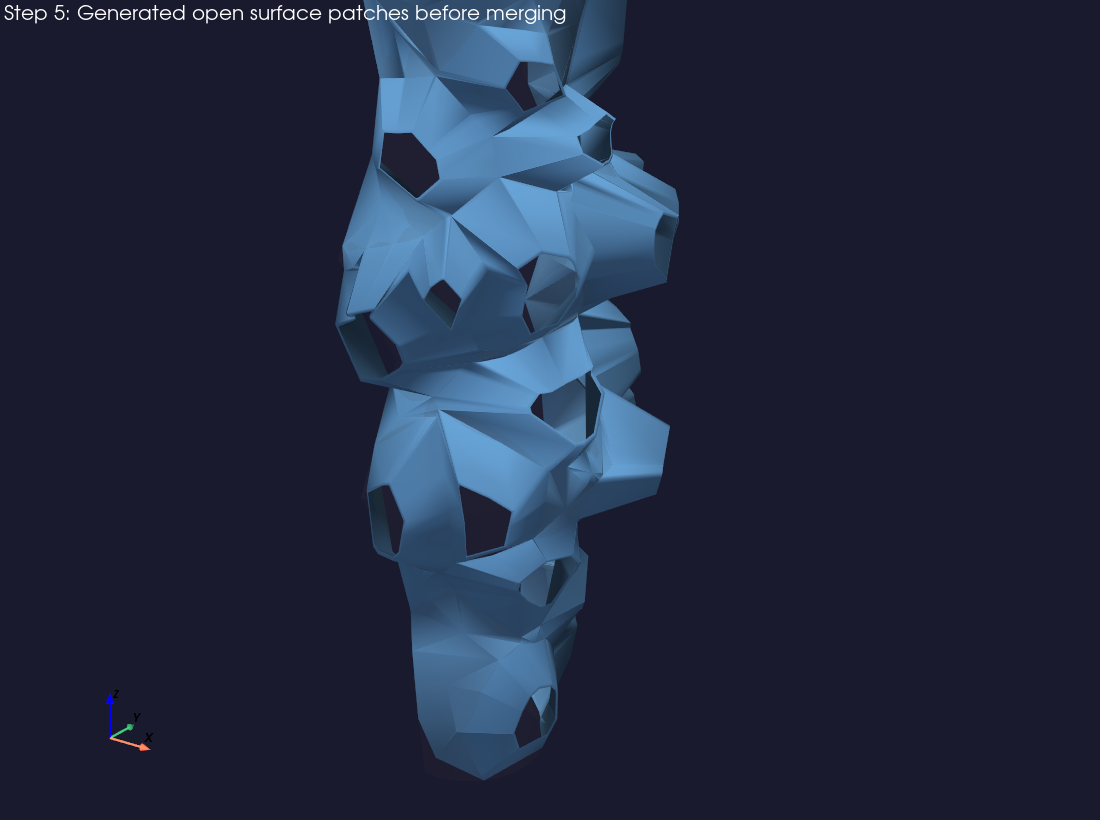

### Step 5A: Interactive inspection of the unmerged geometry

This opens the unmerged open patches in a native PyVista window so you can orbit, pan, and zoom the geometry before any merge or later scaling is applied.

In [11]:
mesh_cleanup = clean_meshes_without_naked_edges(
    analysis_output_meshes,
    tolerance=active_surface_config.line_tolerance,
)
merge_ready_output_meshes = list(mesh_cleanup.kept_meshes)
merge_ready_output_surfaces = list(mesh_cleanup.kept_surface_meshes)
removed_output_mesh_indices = list(mesh_cleanup.removed_indices)
generated_surface = remove_closed_regions(_merge_meshes(merge_ready_output_meshes)) if merge_ready_output_meshes else half_surface

generated_bounds = generated_surface.bounds if generated_surface.n_points else half_surface.bounds
generated_target = generated_surface.center if generated_surface.n_points else half_surface.center

show_step(
    "Step 5: Show the generated open surface patches before merging",
    "This cell keeps the original patch result visible on its own. Each large rebuilt polyline now generates two consecutive loft bands: base to the first moved scaled curve, then first moved scaled curve to the second moved scaled curve at `0.9` of the first scale factor. The extrusion vector still comes only from the fitted-circle center shift around the initial loft bounding-box center.",
)
print(f"Average volume/length ratio: {curve_result.average_ratio:.4f}")
print(f"Extrusion multiplier: {extrusion_multiplier:.2f}")
print(f"Generated open surface faces after cleanup: {generated_surface.n_cells}")
print(f"Cells removed before merge because they have no naked edges: {len(removed_output_mesh_indices)}")
display_static_scene(
    title="Step 5: Generated open surface patches before merging",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.1,
                "smooth_shading": True,
            },
        ),
        (
            generated_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
)
show_step(
    "Step 5A: Interactive inspection of the unmerged geometry",
    "This opens the unmerged open patches in a native PyVista window so you can orbit, pan, and zoom the geometry before any merge or later scaling is applied.",
)
display_interactive_scene(
    title="Step 5A: Interactive unmerged open patches before scaling",
    bounds=generated_bounds,
    target=generated_target,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.1,
                "smooth_shading": True,
            },
        ),
        (
            generated_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=1.2,
    window_size=(1300, 950),
)


### Step 6: Merge the separate open patches into one larger open unit

This merge starts from the already-open patch result shown in the previous step, so it does not introduce any end caps. The goal here is only to join the existing open surfaces into one larger open geometry while keeping the holes and other naked boundaries available for the later operations.

Merged open unit faces: 2472
Merged open unit connected regions: 1
Scaling origin from initial loft bounding box center: [0.0, 0.0, 46.830000000000005]


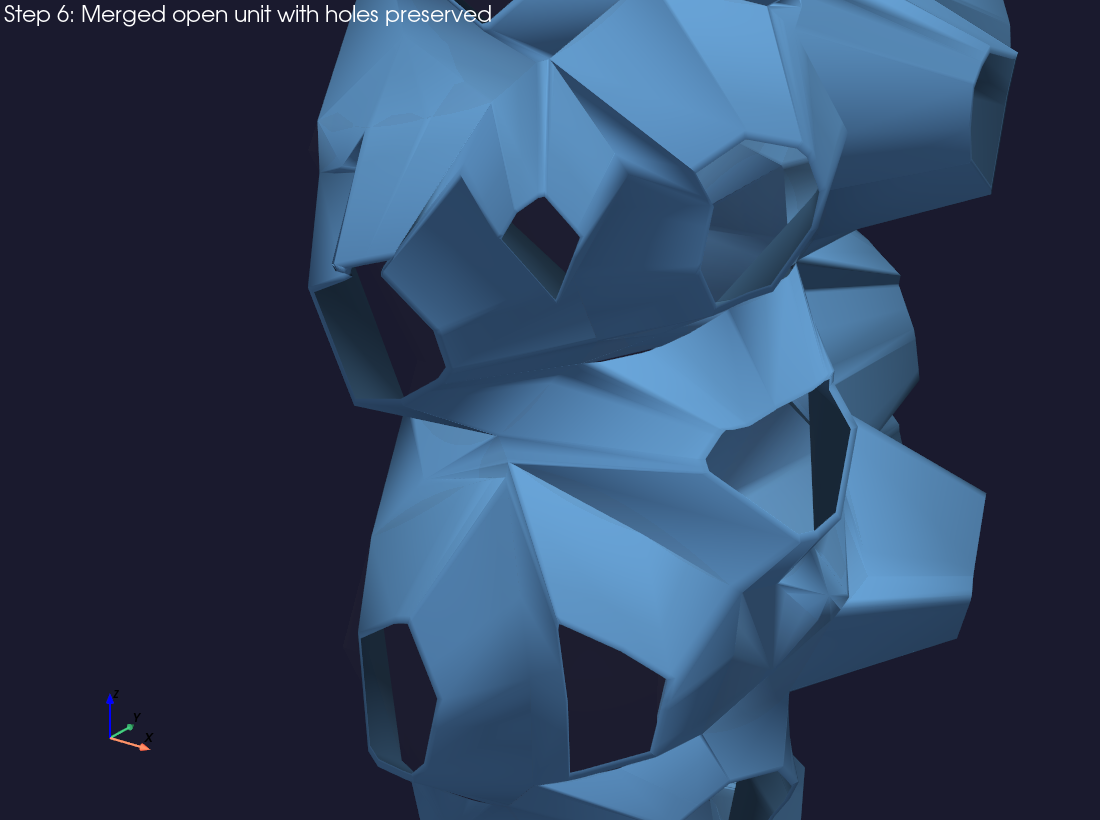

### Step 6A: Interactive inspection of the merged open unit

This opens the merged open unit in a native PyVista window so you can orbit, pan, and zoom the geometry after merging but before creating the scaled copy.

In [12]:
# Merge the cleaned open patches into one larger open unit.
# Any per-cell surface without naked edges was removed in the previous cleanup step.
joined_unit_open_surface = generated_surface.copy(deep=True) if generated_surface.n_points else pv.PolyData()
joined_unit_scene_bounds = padded_scene_bounds(
    joined_unit_open_surface.bounds if joined_unit_open_surface.n_points else generated_bounds,
    padding_fraction=0.04,
    min_padding=0.8,
)
joined_region_count = count_connected_regions(joined_unit_open_surface)

show_step(
    "Step 6: Merge the separate open patches into one larger open unit",
    "This merge starts from the already-open patch result shown in the previous step, so it does not introduce any end caps. The goal here is only to join the existing open surfaces into one larger open geometry while keeping the holes and other naked boundaries available for the later operations.",
)
print(f"Merged open unit faces: {joined_unit_open_surface.n_cells}")
print(f"Merged open unit connected regions: {joined_region_count}")
print(f"Scaling origin from initial loft bounding box center: {initial_loft_bbox_center.tolist()}")
display_static_scene(
    title="Step 6: Merged open unit with holes preserved",
    bounds=joined_unit_scene_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.06,
                "smooth_shading": True,
            },
        ),
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=2.4,
)
show_step(
    "Step 6A: Interactive inspection of the merged open unit",
    "This opens the merged open unit in a native PyVista window so you can orbit, pan, and zoom the geometry after merging but before creating the scaled copy.",
)
display_interactive_scene(
    title="Step 6A: Interactive merged open unit before scaling",
    bounds=joined_unit_scene_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            half_surface,
            {
                "color": "#808080",
                "opacity": 0.06,
                "smooth_shading": True,
            },
        ),
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=1.25,
    window_size=(1300, 950),
)


### Step 7: Make the scaled second open unit

This cell takes the already merged open unit and builds a second open unit by scaling it in `X` and `Y` around the center of the initial full loft bounding box while keeping `Z` unchanged.

Planar scaling (X, Y) with Z fixed: (0.50, 0.50)
Scaling pivot: [0.0, 0.0, 46.830000000000005]
Scaled open unit faces: 2472
Scaled open unit connected regions: 1


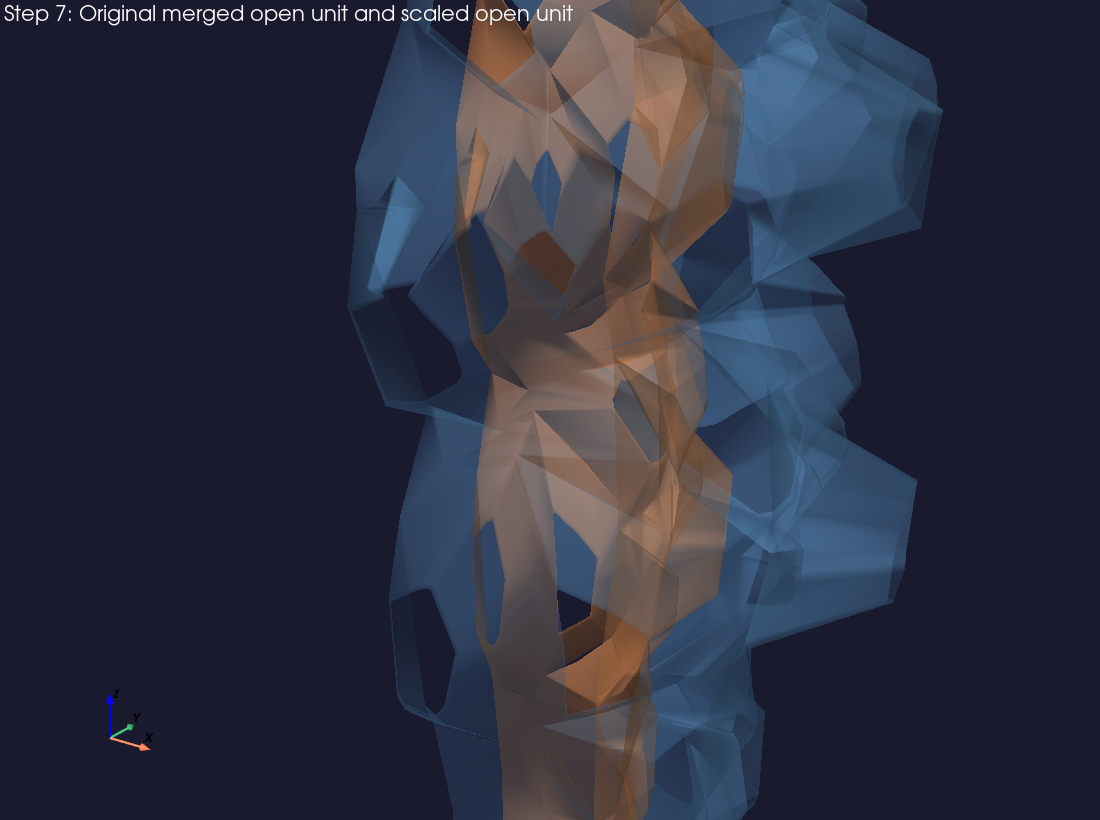

In [13]:
# Create the second open unit by scaling the merged geometry in X and Y while leaving Z unchanged.
# The scaling pivot is the center of the initial full-loft bounding box.
scaled_unit_surface = scale_polydata_in_xy(
    joined_unit_open_surface,
    center=initial_loft_bbox_center,
    scale_x=scale_x,
    scale_y=scale_y,
)
scaled_unit_region_count = count_connected_regions(scaled_unit_surface)
joined_and_scaled_surface = _merge_meshes(
    [mesh for mesh in [joined_unit_open_surface, scaled_unit_surface] if mesh.n_cells > 0]
)
joined_and_scaled_bounds = padded_scene_bounds(
    joined_and_scaled_surface.bounds if joined_and_scaled_surface.n_points else joined_unit_scene_bounds,
    padding_fraction=0.06,
    min_padding=0.8,
)

show_step(
    "Step 7: Make the scaled second open unit",
    "This cell takes the already merged open unit and builds a second open unit by scaling it in `X` and `Y` around the center of the initial full loft bounding box while keeping `Z` unchanged.",
)
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Scaled open unit faces: {scaled_unit_surface.n_cells}")
print(f"Scaled open unit connected regions: {scaled_unit_region_count}")
display_static_scene(
    title="Step 7: Original merged open unit and scaled open unit",
    bounds=joined_and_scaled_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 0.45,
                "smooth_shading": True,
            },
        ),
        (
            scaled_unit_surface,
            {
                "color": "#f59f66",
                "opacity": 0.75,
                "smooth_shading": True,
            },
        ),
    ],
    zoom_factor=2.1,
)


### Step 8: Inspect the naked edges on both open units

The cyan curves are the naked edges of the merged source unit and the magenta curves are the naked edges of the scaled unit. This is the checkpoint for verifying that the boundaries you are about to loft are really just the exterior loops and intended holes, now with the scaled copy derived from the initial loft bounding-box center.

Source naked edge loops: 49
Scaled naked edge loops: 49


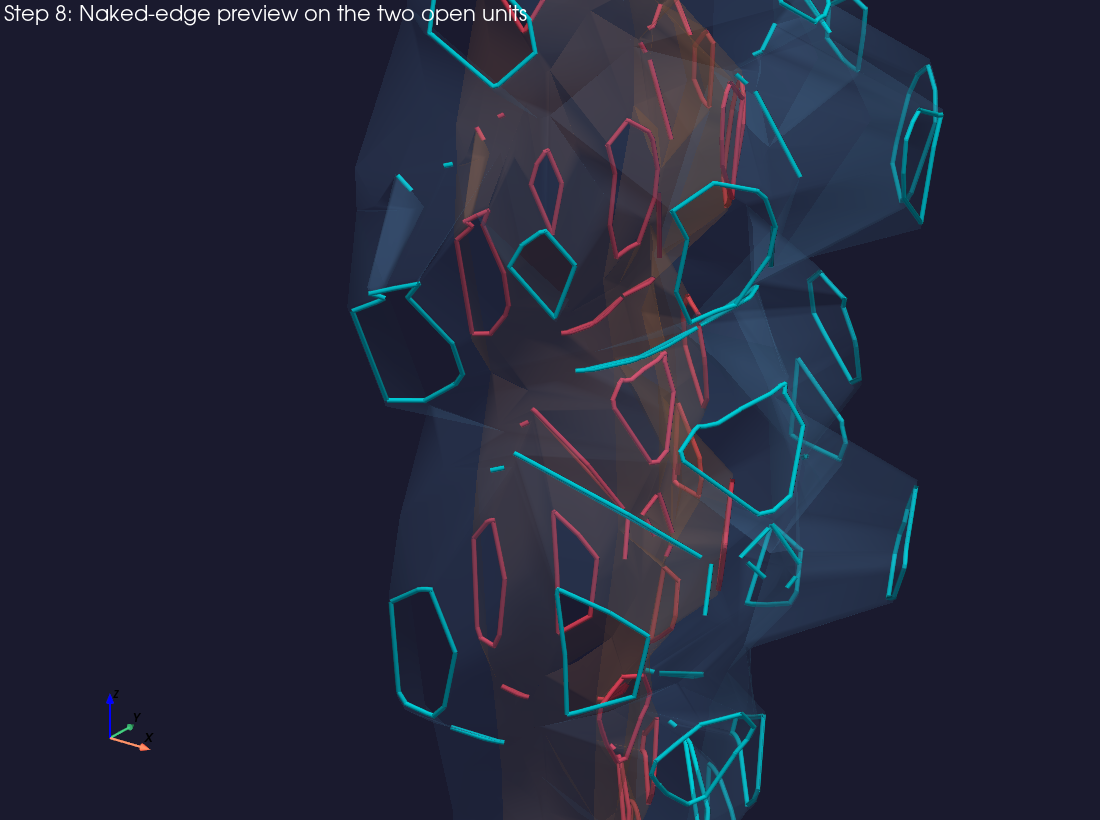

In [14]:
# Inspect the naked edges on both open units before lofting between them.
source_naked_edge_mesh, source_naked_edge_loops = extract_naked_edge_loops(
    joined_unit_open_surface,
    tolerance=active_surface_config.line_tolerance,
)
scaled_naked_edge_mesh, scaled_naked_edge_loops = extract_naked_edge_loops(
    scaled_unit_surface,
    tolerance=active_surface_config.line_tolerance,
)
scaled_source_naked_edge_loops = [
    scale_points_in_xy(
        loop,
        center=initial_loft_bbox_center,
        scale_x=scale_x,
        scale_y=scale_y,
    )
    for loop in source_naked_edge_loops
]
scaled_source_naked_edge_mesh = build_polyline_mesh(scaled_source_naked_edge_loops)

show_step(
    "Step 8: Inspect the naked edges on both open units",
    "The cyan curves are the naked edges of the merged source unit and the magenta curves are the naked edges of the scaled unit. This is the checkpoint for verifying that the boundaries you are about to loft are really just the exterior loops and intended holes, now with the scaled copy derived from the initial loft bounding-box center.",
)
print(f"Source naked edge loops: {len(source_naked_edge_loops)}")
print(f"Scaled naked edge loops: {len(scaled_naked_edge_loops)}")
display_static_scene(
    title="Step 8: Naked-edge preview on the two open units",
    bounds=joined_and_scaled_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            joined_unit_open_surface,
            {
                "color": "#72b7ff",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
        (
            scaled_unit_surface,
            {
                "color": "#f59f66",
                "opacity": 0.18,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            source_naked_edge_mesh,
            {
                "color": "#00e5ff",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
        (
            scaled_naked_edge_mesh,
            {
                "color": "#ff4d6d",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=2.1,
)


### Step 9: Loft between the naked edges and assemble the shell

This final cell builds loft bands between the source naked-edge loops and their scaled counterparts, then merges those lofts with the two open units. The loft directions inherit the same scaling pivot from the initial loft bounding-box center, and the last naked-edge count stays visible as a direct closure check.

Boundary loft faces: 1294
Assembled shell faces: 6238
Assembled shell connected regions: 1
Remaining naked edge loops after assembly: 0


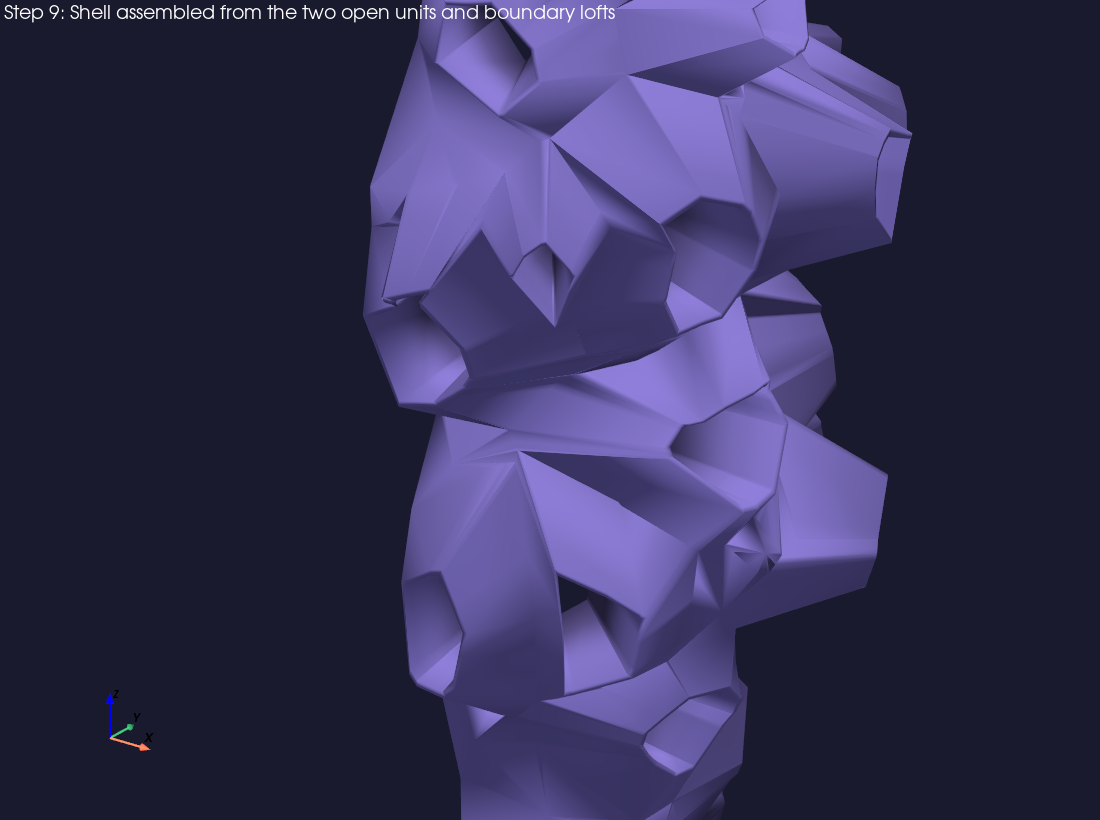

In [15]:
# Loft between the matching naked-edge loops, then merge the loft bands with the two open units.
boundary_loft_meshes = [
    _loft_between_polylines(source_loop, target_loop)
    for source_loop, target_loop in zip(source_naked_edge_loops, scaled_source_naked_edge_loops)
]
boundary_loft_surface = _merge_meshes(boundary_loft_meshes)
closed_shell_surface = _merge_meshes(
    [
        mesh
        for mesh in [joined_unit_open_surface, scaled_unit_surface, boundary_loft_surface]
        if mesh.n_cells > 0
    ]
)
closed_region_count = count_connected_regions(closed_shell_surface)
final_naked_edge_mesh, final_naked_edge_loops = extract_naked_edge_loops(
    closed_shell_surface,
    tolerance=active_surface_config.line_tolerance,
)
closed_shell_bounds = padded_scene_bounds(
    closed_shell_surface.bounds if closed_shell_surface.n_points else joined_and_scaled_bounds,
    padding_fraction=0.05,
    min_padding=0.8,
)

show_step(
    "Step 9: Loft between the naked edges and assemble the shell",
    "This final cell builds loft bands between the source naked-edge loops and their scaled counterparts, then merges those lofts with the two open units. The loft directions inherit the same scaling pivot from the initial loft bounding-box center, and the last naked-edge count stays visible as a direct closure check.",
)
print(f"Boundary loft faces: {boundary_loft_surface.n_cells}")
print(f"Assembled shell faces: {closed_shell_surface.n_cells}")
print(f"Assembled shell connected regions: {closed_region_count}")
print(f"Remaining naked edge loops after assembly: {len(final_naked_edge_loops)}")
display_static_scene(
    title="Step 9: Shell assembled from the two open units and boundary lofts",
    bounds=closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 6,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=1.9,
)


In [16]:
# Show the assembled geometry in an interactive 3D viewer so you can orbit, pan, and zoom.
show_step(
    "Step 10: Interactive 3D inspection of the assembled geometry",
    "This interactive check now opens in a native PyVista window instead of the notebook html backend, because the installed PyVista version still requires `trame` for that notebook path. The native window supports orbit, pan, and zoom without that extra dependency.",
)
display_interactive_scene(
    title="Step 10: Interactive assembled geometry",
    bounds=closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=2.0,
    window_size=(1300, 950),
)


### Step 10: Interactive 3D inspection of the assembled geometry

This interactive check now opens in a native PyVista window instead of the notebook html backend, because the installed PyVista version still requires `trame` for that notebook path. The native window supports orbit, pan, and zoom without that extra dependency.

In [17]:
# Derive external-line candidates from naked edges before the per-cell outputs are merged together.
# The filter explodes every naked-edge loop into 2-point segments, measures midpoint-to-midpoint proximity,
# and excludes segments whose midpoint has another midpoint inside the chosen neighbor distance.
show_step(
    "Step 10A: Interactive external-line candidates from pre-merge naked edges",
    "This cell extracts naked edges from each generated output patch before those patches are merged together, shatters the loops into simple 2-point line segments, and excludes any segment whose midpoint has another segment midpoint within a chosen distance. Use the controls, then click the button to open the interactive native PyVista view.",
)


def segment_polyline(polyline: np.ndarray) -> list[np.ndarray]:
    points = np.asarray(polyline, dtype=float)
    if len(points) < 2:
        return []
    return [points[index : index + 2].copy() for index in range(len(points) - 1)]


premerge_patch_surfaces = list(mesh_cleanup.kept_surface_meshes)
premerge_naked_edge_loops = [
    loop
    for per_cell_loops in mesh_cleanup.naked_edge_loops_by_mesh
    for loop in per_cell_loops
]

premerge_naked_edge_segments: list[np.ndarray] = [
    segment
    for loop in premerge_naked_edge_loops
    for segment in segment_polyline(loop)
]
premerge_naked_edge_segment_lengths = np.array(
    [float(np.linalg.norm(segment[1] - segment[0])) for segment in premerge_naked_edge_segments],
    dtype=float,
)
premerge_naked_edge_midpoints = np.array(
    [segment.mean(axis=0) for segment in premerge_naked_edge_segments],
    dtype=float,
) if premerge_naked_edge_segments else np.zeros((0, 3), dtype=float)

if len(premerge_naked_edge_midpoints) > 1:
    midpoint_delta = premerge_naked_edge_midpoints[:, None, :] - premerge_naked_edge_midpoints[None, :, :]
    midpoint_distance_matrix = np.linalg.norm(midpoint_delta, axis=2)
    np.fill_diagonal(midpoint_distance_matrix, np.inf)
    nearest_midpoint_distances = midpoint_distance_matrix.min(axis=1)
else:
    nearest_midpoint_distances = np.full(len(premerge_naked_edge_segments), np.inf, dtype=float)

finite_nearest_midpoint_distances = nearest_midpoint_distances[np.isfinite(nearest_midpoint_distances)]
default_neighbor_distance = (
    float(np.percentile(finite_nearest_midpoint_distances, 25))
    if len(finite_nearest_midpoint_distances) > 0
    else float(active_surface_config.line_tolerance * 10.0)
)
max_neighbor_distance = (
    float(max(finite_nearest_midpoint_distances.max() * 1.1, default_neighbor_distance * 1.5, active_surface_config.line_tolerance * 20.0))
    if len(finite_nearest_midpoint_distances) > 0
    else float(active_surface_config.line_tolerance * 50.0)
)
step_neighbor_distance = max(max_neighbor_distance / 200.0, active_surface_config.line_tolerance / 2.0)


def filter_segments_by_midpoint_neighbor_distance(
    neighbor_distance: float,
) -> tuple[list[np.ndarray], list[np.ndarray], np.ndarray, np.ndarray]:
    if not premerge_naked_edge_segments:
        return [], [], np.zeros((0, 3), dtype=float), np.zeros((0, 3), dtype=float)

    keep_mask = nearest_midpoint_distances > neighbor_distance
    kept_segments = [segment for keep, segment in zip(keep_mask, premerge_naked_edge_segments, strict=True) if keep]
    excluded_segments = [segment for keep, segment in zip(keep_mask, premerge_naked_edge_segments, strict=True) if not keep]
    kept_midpoints = premerge_naked_edge_midpoints[keep_mask]
    excluded_midpoints = premerge_naked_edge_midpoints[~keep_mask]
    return kept_segments, excluded_segments, kept_midpoints, excluded_midpoints


external_line_control_summary = widgets.HTML()
external_line_neighbor_distance = widgets.FloatSlider(
    value=default_neighbor_distance,
    min=0.0,
    max=max_neighbor_distance,
    step=step_neighbor_distance,
    description="NN dist",
    readout_format=".3f",
    continuous_update=False,
    layout=widgets.Layout(width="420px"),
)
external_line_show_excluded = widgets.Checkbox(
    value=True,
    description="Show excluded segments",
)
external_line_show_midpoints = widgets.Checkbox(
    value=True,
    description="Show midpoints",
)
external_line_open_view = widgets.Button(
    description="Open interactive external-line view",
    button_style="success",
)
external_line_output = widgets.Output()


def update_external_line_summary(*_: object) -> None:
    kept_segments, excluded_segments, _, _ = filter_segments_by_midpoint_neighbor_distance(
        external_line_neighbor_distance.value,
    )
    kept_lengths = np.array([np.linalg.norm(segment[1] - segment[0]) for segment in kept_segments], dtype=float)
    excluded_lengths = np.array([np.linalg.norm(segment[1] - segment[0]) for segment in excluded_segments], dtype=float)
    external_line_control_summary.value = (
        f"<b>Pre-merge patches:</b> {len(premerge_patch_surfaces)}"
        f" | <b>Naked-edge loops:</b> {len(premerge_naked_edge_loops)}"
        f" | <b>2-point segments:</b> {len(premerge_naked_edge_segments)}"
        f" | <b>Kept:</b> {len(kept_segments)}"
        f" | <b>Excluded:</b> {len(excluded_segments)}"
        f" | <b>Threshold:</b> {external_line_neighbor_distance.value:.3f}"
        f" | <b>Kept mean length:</b> {(kept_lengths.mean() if len(kept_lengths) > 0 else 0.0):.3f}"
        f" | <b>Excluded mean length:</b> {(excluded_lengths.mean() if len(excluded_lengths) > 0 else 0.0):.3f}"
    )


for widget in [external_line_neighbor_distance, external_line_show_excluded, external_line_show_midpoints]:
    widget.observe(update_external_line_summary, names="value")


def open_external_line_view(_: widgets.Button) -> None:
    kept_segments, excluded_segments, kept_midpoints, excluded_midpoints = filter_segments_by_midpoint_neighbor_distance(
        external_line_neighbor_distance.value,
    )
    kept_mesh = build_polyline_mesh(kept_segments)
    excluded_mesh = build_polyline_mesh(excluded_segments)

    fit_bounds_candidates: list[tuple[float, float, float, float, float, float]] = []
    if kept_mesh.n_points > 0:
        fit_bounds_candidates.append(kept_mesh.bounds)
    if external_line_show_excluded.value and excluded_mesh.n_points > 0:
        fit_bounds_candidates.append(excluded_mesh.bounds)
    if not fit_bounds_candidates:
        fit_bounds_candidates.append(generated_bounds)
    fit_bounds = padded_scene_bounds(
        merge_bounds(fit_bounds_candidates),
        padding_fraction=0.08,
        min_padding=0.8,
    )
    fit_target = center_from_bounds(fit_bounds)

    with external_line_output:
        external_line_output.clear_output(wait=True)
        display(Markdown(
            f"Opening interactive external-line view with `{len(kept_segments)}` kept segments and `{len(excluded_segments)}` excluded segments at midpoint-neighbor threshold `{external_line_neighbor_distance.value:.3f}`."
        ))

    display_interactive_scene(
        title="Step 10A: Pre-merge naked-edge segment filter",
        bounds=fit_bounds,
        target=fit_target,
        meshes=[
            (
                generated_surface,
                {
                    "color": "#6b7280",
                    "opacity": 0.12,
                    "smooth_shading": True,
                },
            ),
        ],
        line_meshes=[
            (
                kept_mesh,
                {
                    "color": "#00e676",
                    "line_width": 6,
                    "opacity": 1.0,
                },
            ),
            *([
                (
                    excluded_mesh,
                    {
                        "color": "#ff5c5c",
                        "line_width": 3,
                        "opacity": 0.45,
                        "style": "wireframe",
                    },
                ),
            ] if external_line_show_excluded.value and excluded_mesh.n_points > 0 else []),
        ],
        point_sets=[
            *([
                (
                    kept_midpoints,
                    {
                        "color": "#8dffb3",
                        "point_size": 12,
                        "render_points_as_spheres": True,
                    },
                ),
            ] if external_line_show_midpoints.value and len(kept_midpoints) > 0 else []),
            *([
                (
                    excluded_midpoints,
                    {
                        "color": "#ffb3b3",
                        "point_size": 9,
                        "render_points_as_spheres": True,
                    },
                ),
            ] if external_line_show_midpoints.value and external_line_show_excluded.value and len(excluded_midpoints) > 0 else []),
        ],
        zoom_factor=1.4,
        window_size=(1300, 950),
    )


external_line_open_view.on_click(open_external_line_view)
update_external_line_summary()
display(
    widgets.VBox(
        [
            external_line_control_summary,
            widgets.HBox(
                [
                    external_line_neighbor_distance,
                    widgets.VBox(
                        [
                            external_line_show_excluded,
                            external_line_show_midpoints,
                            external_line_open_view,
                        ]
                    ),
                ]
            ),
            external_line_output,
        ]
    )
)

print(f"Pre-merge output patches inspected: {len(premerge_patch_surfaces)}")
print(f"Pre-merge naked-edge loops: {len(premerge_naked_edge_loops)}")
print(f"Shattered 2-point segments: {len(premerge_naked_edge_segments)}")
if len(finite_nearest_midpoint_distances) > 0:
    print(
        "Nearest midpoint distance stats - "
        f"min: {finite_nearest_midpoint_distances.min():.4f}, "
        f"max: {finite_nearest_midpoint_distances.max():.4f}, "
        f"mean: {finite_nearest_midpoint_distances.mean():.4f}"
    )
else:
    print("Nearest midpoint distance stats: only zero or one segment was available.")
print("Adjust the midpoint-neighbor threshold and click the button to inspect the resulting kept external-line candidates.")

### Step 10A: Interactive external-line candidates from pre-merge naked edges

This cell extracts naked edges from each generated output patch before those patches are merged together, shatters the loops into simple 2-point line segments, and excludes any segment whose midpoint has another segment midpoint within a chosen distance. Use the controls, then click the button to open the interactive native PyVista view.

Pre-merge output patches inspected: 48
Pre-merge naked-edge loops: 69
Shattered 2-point segments: 1416
Nearest midpoint distance stats - min: 0.0000, max: 7.7373, mean: 0.3913
Adjust the midpoint-neighbor threshold and click the button to inspect the resulting kept external-line candidates.


### Step 10B: Join and scale the external-line curves

This cell takes the currently kept 2-point external-line segments from Step 10A, joins every directly connectable chain into a continuous curve, sorts the resulting curves by length for stable numbering, and creates the scaled partner set using the same non-uniform `X/Y` scaling around the initial loft bounding-box center.

Midpoint-neighbor threshold used: 0.0000
Kept 2-point segments entering the join: 912
Excluded 2-point segments at this threshold: 504
Joined curves before isolation filter: 71
Isolated curves removed (no shared vertices with neighbors): 57
Connected external curves kept: 14
Joined curve lengths - min: 1.2728, max: 409.3376, mean: 42.6172
Scaling pivot: [0.0, 0.0, 46.830000000000005]
Planar scaling (X, Y) with Z fixed: (0.50, 0.50)


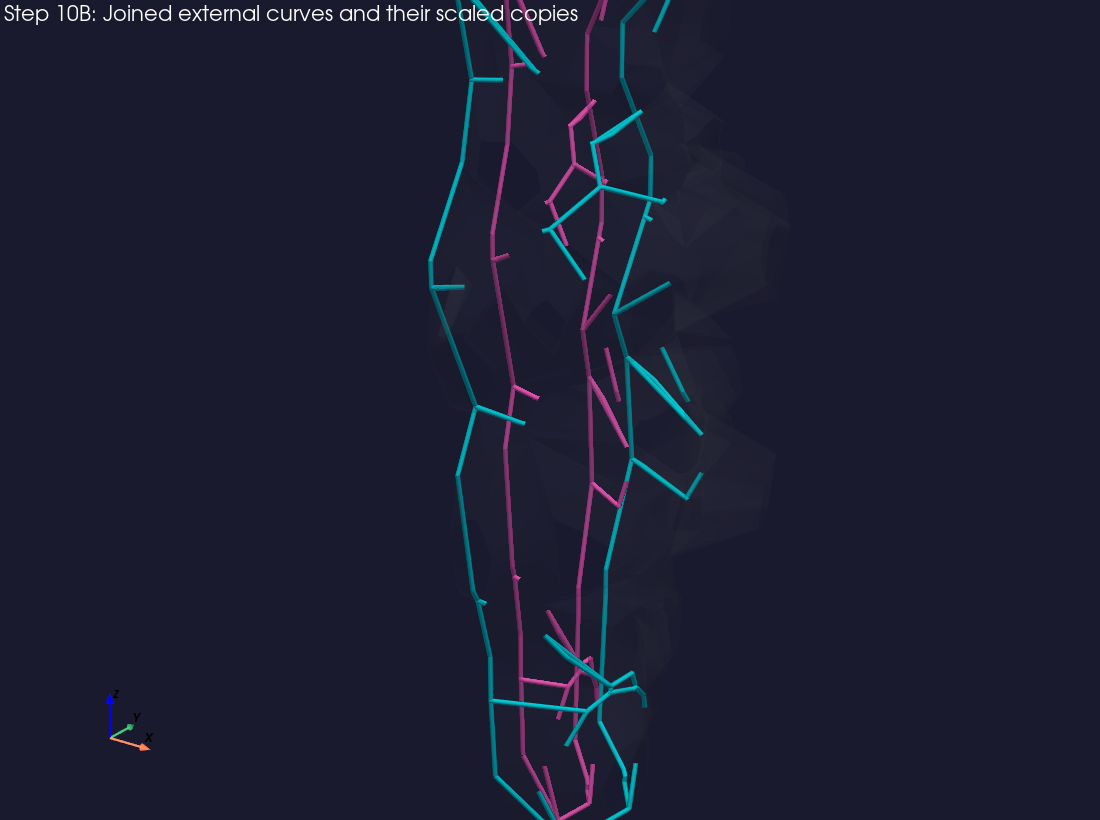

In [18]:
# Join the kept external-line segments into the longest continuous curves that can be formed,
# then build the scaled companion curve set with the same non-uniform loft scaling.
show_step(
    "Step 10B: Join and scale the external-line curves",
    "This cell takes the currently kept 2-point external-line segments from Step 10A, joins every directly connectable chain into a continuous curve, sorts the resulting curves by length for stable numbering, and creates the scaled partner set using the same non-uniform `X/Y` scaling around the initial loft bounding-box center.",
)


def polyline_length(polyline: np.ndarray) -> float:
    points = np.asarray(polyline, dtype=float)
    if len(points) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(points, axis=0), axis=1).sum())



selected_external_segments, excluded_external_segments, _, _ = filter_segments_by_midpoint_neighbor_distance(
    external_line_neighbor_distance.value,
)
all_joined_external_curves = join_two_point_segments_into_polylines(
    selected_external_segments,
    tolerance=active_surface_config.line_tolerance,
)
all_joined_external_curves = sorted(
    all_joined_external_curves,
    key=lambda polyline: (
        -polyline_length(polyline),
        round(float(polyline[0, 2]), 6) if len(polyline) > 0 else 0.0,
        round(float(polyline[0, 1]), 6) if len(polyline) > 0 else 0.0,
        round(float(polyline[0, 0]), 6) if len(polyline) > 0 else 0.0,
    ),
)
joined_external_curves, connected_curve_indices, isolated_curve_indices = filter_isolated_polylines(
    all_joined_external_curves,
    tolerance=active_surface_config.line_tolerance,
)
scaled_joined_external_curves = [
    scale_points_in_xy(
        curve,
        center=initial_loft_bbox_center,
        scale_x=scale_x,
        scale_y=scale_y,
    )
    for curve in joined_external_curves
]
joined_external_curve_mesh = build_polyline_mesh(joined_external_curves)
scaled_joined_external_curve_mesh = build_polyline_mesh(scaled_joined_external_curves)
joined_external_curve_lengths = np.array([polyline_length(curve) for curve in joined_external_curves], dtype=float)

external_curve_preview_bounds_candidates = [generated_bounds]
if joined_external_curve_mesh.n_points > 0:
    external_curve_preview_bounds_candidates.append(joined_external_curve_mesh.bounds)
if scaled_joined_external_curve_mesh.n_points > 0:
    external_curve_preview_bounds_candidates.append(scaled_joined_external_curve_mesh.bounds)
external_curve_preview_bounds = padded_scene_bounds(
    merge_bounds(external_curve_preview_bounds_candidates),
    padding_fraction=0.08,
    min_padding=0.8,
)

print(f"Midpoint-neighbor threshold used: {external_line_neighbor_distance.value:.4f}")
print(f"Kept 2-point segments entering the join: {len(selected_external_segments)}")
print(f"Excluded 2-point segments at this threshold: {len(excluded_external_segments)}")
print(f"Joined curves before isolation filter: {len(all_joined_external_curves)}")
print(f"Isolated curves removed (no shared vertices with neighbors): {len(isolated_curve_indices)}")
print(f"Connected external curves kept: {len(joined_external_curves)}")
if len(joined_external_curve_lengths) > 0:
    print(
        "Joined curve lengths - "
        f"min: {joined_external_curve_lengths.min():.4f}, "
        f"max: {joined_external_curve_lengths.max():.4f}, "
        f"mean: {joined_external_curve_lengths.mean():.4f}"
    )
else:
    print("Joined curve lengths: no curves were formed.")
print(f"Scaling pivot: {initial_loft_bbox_center.tolist()}")
print(f"Planar scaling (X, Y) with Z fixed: ({scale_x:.2f}, {scale_y:.2f})")

display_static_scene(
    title="Step 10B: Joined external curves and their scaled copies",
    bounds=external_curve_preview_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            generated_surface,
            {
                "color": "#6b7280",
                "opacity": 0.08,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            joined_external_curve_mesh,
            {
                "color": "#00e5ff",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
        (
            scaled_joined_external_curve_mesh,
            {
                "color": "#ff5fd2",
                "line_width": 5,
                "opacity": 0.95,
            },
        ),
    ],
    zoom_factor=1.35,
)


### Step 10C: Loft the joined external curves and merge them into the shell

This cell lofts every joined external curve to its scaled partner, keeps those loft bands together as one new surface set, and merges that result into the already assembled shell from Step 9 so you can see the added external closure geometry separately and in context.

External curve lofts created: 14
Closed lofts removed (no boundary edges): 0
External curve lofts kept: 14
External curve loft faces: 370
Pre-resolve shell faces: 6608
Extended shell faces after non-manifold resolution: 6544
Extended shell connected regions: 1
Remaining naked edge loops after external loft merge: 10


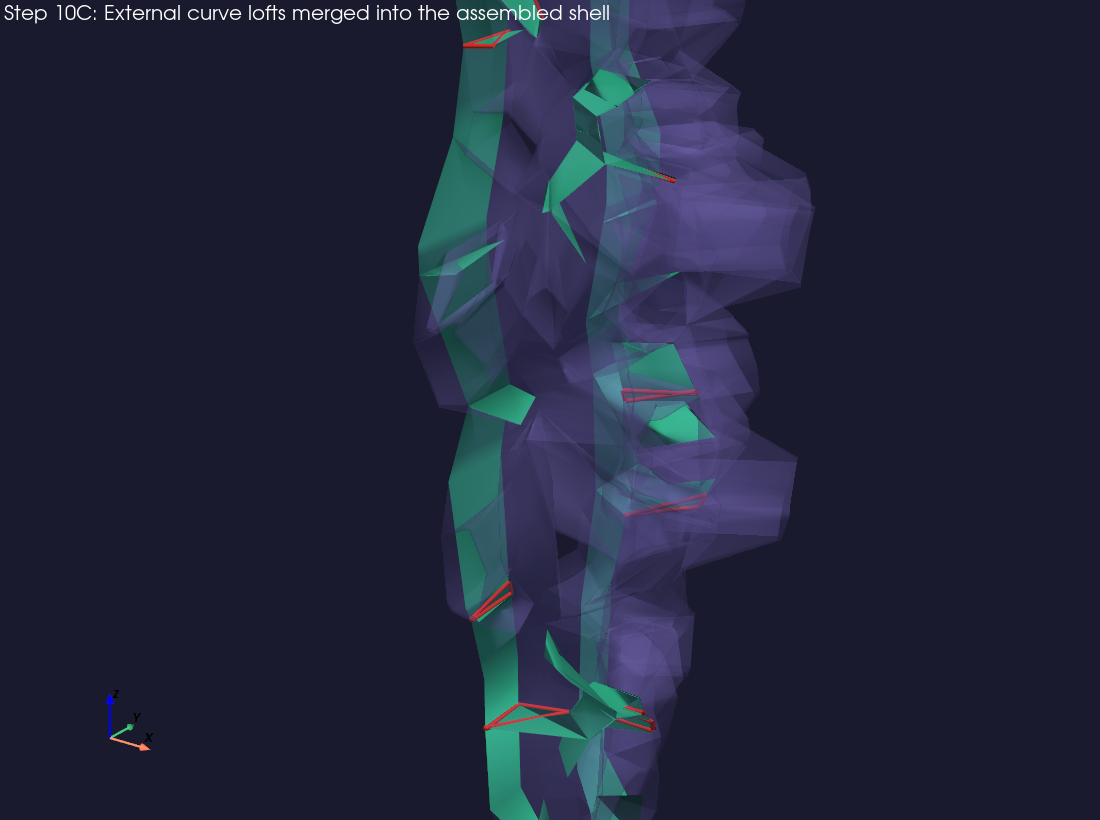

In [19]:
# Loft between each joined external curve and its scaled counterpart, then merge those lofts into the assembled shell.
show_step(
    "Step 10C: Loft the joined external curves and merge them into the shell",
    "This cell lofts every joined external curve to its scaled partner, keeps those loft bands together as one new surface set, and merges that result into the already assembled shell from Step 9 so you can see the added external closure geometry separately and in context.",
)

all_external_curve_loft_meshes = [
    _loft_between_polylines(source_curve, target_curve)
    for source_curve, target_curve in zip(joined_external_curves, scaled_joined_external_curves, strict=True)
    if len(source_curve) >= 2 and len(target_curve) >= 2
]
external_curve_loft_meshes, ext_kept_indices, ext_removed_indices = filter_closed_meshes(
    all_external_curve_loft_meshes,
)
external_curve_loft_surface = _merge_meshes(external_curve_loft_meshes)
pre_resolve_shell = _merge_meshes(
    [
        mesh
        for mesh in [closed_shell_surface, external_curve_loft_surface]
        if mesh.n_cells > 0
    ]
)
extended_closed_shell_surface = resolve_non_manifold_faces(pre_resolve_shell)
extended_closed_region_count = count_connected_regions(extended_closed_shell_surface)
extended_final_naked_edge_mesh, extended_final_naked_edge_loops = extract_naked_edge_loops(
    extended_closed_shell_surface,
    tolerance=active_surface_config.line_tolerance,
)
extended_closed_shell_bounds = padded_scene_bounds(
    extended_closed_shell_surface.bounds if extended_closed_shell_surface.n_points else closed_shell_bounds,
    padding_fraction=0.05,
    min_padding=0.8,
)

print(f"External curve lofts created: {len(all_external_curve_loft_meshes)}")
print(f"Closed lofts removed (no boundary edges): {len(ext_removed_indices)}")
print(f"External curve lofts kept: {len(external_curve_loft_meshes)}")
print(f"External curve loft faces: {external_curve_loft_surface.n_cells}")
print(f"Pre-resolve shell faces: {pre_resolve_shell.n_cells}")
print(f"Extended shell faces after non-manifold resolution: {extended_closed_shell_surface.n_cells}")
print(f"Extended shell connected regions: {extended_closed_region_count}")
print(f"Remaining naked edge loops after external loft merge: {len(extended_final_naked_edge_loops)}")

display_static_scene(
    title="Step 10C: External curve lofts merged into the assembled shell",
    bounds=extended_closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 0.22,
                "smooth_shading": True,
            },
        ),
        (
            external_curve_loft_surface,
            {
                "color": "#2ee6a6",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            extended_final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=1.4,
)


In [20]:
# Open an interactive view of the shell after the external curve lofts are merged in.
show_step(
    "Step 10D: Interactive inspection of the shell with external curve lofts",
    "This interactive view opens the updated shell after the joined external-curve lofts are merged in. The added lofts are shown in bright green on top of the translucent assembled shell, and any remaining naked edges stay visible in red for another closure check.",
)

display_interactive_scene(
    title="Step 10D: Interactive shell with external curve lofts",
    bounds=extended_closed_shell_bounds,
    target=initial_loft_bbox_center,
    meshes=[
        (
            extended_closed_shell_surface,
            {
                "color": "#9b8cff",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
        (
            external_curve_loft_surface,
            {
                "color": "#2ee6a6",
                "opacity": 1.0,
                "smooth_shading": True,
            },
        ),
    ],
    line_meshes=[
        (
            extended_final_naked_edge_mesh,
            {
                "color": "#ff3b30",
                "line_width": 5,
                "opacity": 1.0,
            },
        ),
    ],
    zoom_factor=2.0,
    window_size=(1300, 950),
)


### Step 10D: Interactive inspection of the shell with external curve lofts

This interactive view opens the updated shell after the joined external-curve lofts are merged in. The added lofts are shown in bright green on top of the translucent assembled shell, and any remaining naked edges stay visible in red for another closure check.

In [21]:
pre_repair_report = build_mesh_printability_report(
    extended_closed_shell_surface,
    tolerance=active_surface_config.line_tolerance,
)
print(
    "Pre-repair check - "
    f"faces: {pre_repair_report.face_count}, "
    f"non-manifold edges: {pre_repair_report.non_manifold_edge_count}, "
    f"boundary edges: {pre_repair_report.boundary_edge_count}, "
    f"boundary loops: {pre_repair_report.boundary_loop_count}"
)

closed_shell = unify_mesh_normals(
    close_mesh_boundaries(
        extended_closed_shell_surface,
        tolerance=active_surface_config.line_tolerance,
    )
)
for _arr_key in list(closed_shell.cell_data.keys()):
    del closed_shell.cell_data[_arr_key]
closed_report = build_mesh_printability_report(
    closed_shell,
    tolerance=active_surface_config.line_tolerance,
)
print(
    "After close_mesh_boundaries - "
    f"faces: {closed_report.face_count}, "
    f"non-manifold edges: {closed_report.non_manifold_edge_count}, "
    f"boundary edges: {closed_report.boundary_edge_count}, "
    f"closed: {closed_report.is_closed}, "
    f"printable: {closed_report.is_printable}"
)

default_stl_path = Path("exports") / "lofted_surface_voronoi_shell.stl"
if closed_report.is_printable:
    exported_stl_path = export_mesh_to_stl(
        closed_shell,
        default_stl_path,
        tolerance=active_surface_config.line_tolerance,
        attempt_repair=False,
    )
    print(f"STL exported to: {exported_stl_path}")
else:
    mesh_export_preparation = prepare_mesh_for_export(
        closed_shell,
        tolerance=active_surface_config.line_tolerance,
        attempt_repair=True,
    )
    final_report = mesh_export_preparation.final_report
    print(
        f"Repair attempted: {mesh_export_preparation.repair_method or 'none'} - "
        f"closed: {final_report.is_closed}, "
        f"non-manifold: {final_report.non_manifold_edge_count}, "
        f"boundary: {final_report.boundary_edge_count}"
    )
    default_stl_path.parent.mkdir(parents=True, exist_ok=True)
    mesh_export_preparation.mesh.save(str(default_stl_path))
    print(f"STL saved to: {default_stl_path}")


Pre-repair check - faces: 6544, non-manifold edges: 0, boundary edges: 288, boundary loops: 10
After close_mesh_boundaries - faces: 6824, non-manifold edges: 0, boundary edges: 20, closed: False, printable: False
Repair attempted: close_mesh_boundaries_partial - closed: False, non-manifold: 0, boundary: 20
STL saved to: exports\lofted_surface_voronoi_shell.stl
